# Spatial Distribution and Condition Assessment of *Fraxinus chinensis*  Roxb. in Bogota: A GIS-Based Approach Using WFS Integration

written by *Miguel* *Salamanca* (*24215745*)

## Abstract 
The urban forest of Bogota is dominated by a few key species, with *Fraxinus chinensis* Roxb. (Urapán) being historically significant. However, the health  and spatial density of these trees vary across the city's diverse microclimates and urban fabrics. Understanding their distribution is crucial  for  urban planning and biodiversity management. Despite the availability of  the Urban Tree Census condensed by Bogota Botanical Garden (SIGAU), there is  a need  for a dynamic, integrated analysis that correlates the current state  of Urapán  with administrative boundaries. Furthermore, Ramírez-Sánchez,  Hurtado-Vásquez &  Triana-Gómez ([2020](https://doi.org/10.21500/20275846.4344)) highlight the  need of managing Urapán trees in Bogota due to impacts on their plant health.   The aim of this project is to assess the status of Urapán trees and distribution  in Bogota through a GIS Approach by utilizing Web Feature Services (WFS) allows  for real-time data processing as well as for any other data update, ensuring the analysis remains current with official city records.

## 1. Introduction

Urban forests and urban trees provide essential ecosystem services, ranging from microclimate regulation to psychological well-being. However, when poorly managed or dominated by uniform species composition, they can also generate significant ecosystem disservices (Escobedo *et al.*, [2023](https://doi.org/10.1016/j.scs.2022.104343)). In the high-Andean metropolis of Bogota, Colombia, urban greening strategies have historically relied heavily on a limited palette of exotic species, as outlined in structural management frameworks like the *Manual de Silvicultura Urbana de Bogotá* (Bogota Botanical Garden, 2011). Among these, *Fraxinus chinensis* Roxb. (commonly known as Urapán) has historically been one of the most widely planted individuals, shaping the urban canopy across various socio-economic zones of the city.

Despite its rapid growth and adaptation to urban soils, the massive proliferation of Fraxinus chinensis has triggered critical public health and ecological concerns. From an epidemiological standpoint, the species is a major driver of airborne allergies in the capital; early biochemical assessments confirmed that *Fraxinus chinensis* pollen possesses a high allergenic capacity, inducing strong IgE-mediated respiratory responses among the city's sensitive populations (Rodríguez & Leal, 1997). Furthermore, these public health risks are compounded by a severe, ongoing phytosanitary crisis. For decades, Urapán populations across Bogota have suffered from extensive decline due to specialized pests like *Tropidosteptes chapingoensis (Hemiptera: Miriidae)*, whose biology and destructive feeding habits drastically undermine tree vitality (Pinzón-Florián & Pedreros, 1995). Recent structural evaluations of Bogota’s urban canopy continue to flag Fraxinus chinensis as one of the species exhibiting the highest patterns of physical deterioration, decay, and mortality (Ramírez-Sánchez *et al.*, [2020](https://doi.org/10.21500/20275846.4344)). This vulnerability is unevenly distributed across the city, often overlapping with socio-economically marginalized neighborhoods that are disproportionately exposed to these environmental disservices (Escobedo *et al.*, [2023](https://doi.org/10.1016/j.scs.2022.104343)).

While these rich data streams exist, there remains a technical and methodological gap in seamlessly connecting and processing them within highly scalable computational frameworks. This paper addresses this gap by presenting a reproducible geospatial pipeline developed within a Python-driven Big Data environment (Zen & VSCode). By directly consuming live WFS streams of individual tree locations (Bogota Botanical Garden, [2025](https://geoportal.jbb.gov.co/agc/services/IDECA/CensoArbol/MapServer/WFSServer?request=GetCapabilities&service=WFS)) and administrative polygon boundaries (Bogota District Planning Office, [2020](https://serviciosgis.catastrobogota.gov.co/arcgis/services/ordenamientoterritorial/localidad/MapServer/WFSServer?request=GetCapabilities&service=WFS)), this study models the precise spatial distribution, density, and health status of *Fraxinus chinensis* across Bogota's localities. The resulting framework provides city planners and forest engineers with an automated, scalable decision-support tool to manage public health risks and guide future urban reforestation efforts.

## 2. Methodology

### 2.1 Study area

Table 1. Study area characteristics.

|             **Area (km²)**             |                1776                |
|:--------------------------------------:|:----------------------------------:|
|             **Population**             |          8.962.462 (2019)          |
|       **Mean altitude (m.a.s.l)**      |                2630                |
|    **Mean annual temperature (°C)**    |                7-19                |
|   **Mean annual precipitation (mm)**   |                 866                |
| **Climate classification (Holdridge)** | Moist lower montane forest (bh-MB) |

![Bogotá](../img/Bogota.jpeg)

Figure 1. Study area location and administrative division.

### 2.2 Data sources

Table 2. Data sources.

|                   **Data**                  | **Layer Type** |                                                                                                                                                     **Description**                                                                                                                                                    |                                                                                                              **Source**                                                                                                              |
|:-------------------------------------------:|:--------------:|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------:|:---------------------------------------------------------------------------------------------------------------------------------------:|
|            Bogota Urban Tree Data           |      Point     | Plant census belonging to the species classified as trees, shrubs, palms or tree ferns, located on urban land in the city of Bogota.                                                                                                                                                                                   | Bogota Botanical Garden "José Celestino Mutis", (2025). Bogota Urban Trees. Retrieved from [Urban trees WFS](https://geoportal.jbb.gov.co/agc/services/IDECA/CensoArbol/MapServer/WFSServer?request=GetCapabilities&service=WFS)                  |
| Bogota Administrative Locations' Boundaries |     Polygon    | Municipal political, administrative and territorial division, with clearly defined powers and criteria for the funding and allocation of resources, established by the Municipal Council at the initiative of the relevant mayor, with the aim of addressing the needs of that part of the territory more effectively. | Bogota District Planning Office, (2020). Bogota Locations. Retrieved from [Administrative Division WFS](https://serviciosgis.catastrobogota.gov.co/arcgis/services/ordenamientoterritorial/localidad/MapServer/WFSServer?request=GetCapabilities&service=WFS) |

### 2.3 Workflow diagram

![Methodology](../img/methodology.jpeg)

Figure 2. Methodology workflow.

The methodological framework designed to assess the structural and spatial attributes of Fraxinus chinensis within Bogotá follows a systematic, reproducible geospatial pipeline implemented within a Python-driven Big Data environment (Zed & VSCode). The workflow transitions sequentially from live server-side data ingestion to advanced spatial point pattern analysis, as visually outlined in  

**Data Connection and Import:** The pipeline initiates with the dynamic ingestion of spatial data directly from municipal servers, bypassing manual file downloads to guarantee data provenance and currency. Using Python's OWSLib library, a connection is established with the Web Feature Service (WFS) maintained by the Bogota Botanical Garden (2025) to stream the Bogota Urban Trees point layer, which contains individual coordinates and dendrometric attributes for the city's managed canopy. However, due to persistent server-side connection and authentication constraints, the WFS endpoint for the administrative boundaries could not be reliably accessed during the execution phase. To bypass this technical bottleneck without altering the analytical scope, the polygon geometry defining the boundaries of the city's administrative localities (Bogota Locations) was instead ingested utilizing its official GeoJSON static equivalent provided by the Bogota District Planning Office ([2020](https://serviciosgis.catastrobogota.gov.co/arcgis/services/ordenamientoterritorial/localidad/MapServer/WFSServer?request=GetCapabilities&service=WFS)).

**Data Tidy and Filtering:** Once streamed into the environment, the raw features are parsed into structural dataframes using GeoPandas. The initial step involves auditing the data for topological consistency and standardizing the Coordinate Reference System (CRS) to MAGNA-Sirgas / Orígen Único (EPSG:9377) to ensure precise distance and area calculations. To isolate the target population, programmatic attribute filtering is applied to the dataset. The total urban forest inventory is queried to extract only records where the taxonomic classification matches *Fraxinus chinensis*, generating a dedicated spatial subset while purging incomplete or erroneous records.

**Overall Tree Height Statistical Analysis:** To establish a baseline for comparison, descriptive statistical modeling is performed on the structural dimensions of the entire urban tree population. Height parameters across all species are aggregated city-wide. Measures of central tendency (mean, median) and dispersion (standard deviation, variance) are computed for the total canopy height. This stage serves as a control benchmark, facilitating the identification of structural anomalies, distribution skews, or size-class variances present in the city's overall urban forestry matrix.

**Urapán Tree Height Statistical Analysis:** Following the global assessment, the identical height-based statistical metrics are applied exclusively to the filtered *Fraxinus chinensis* subset. Evaluating the height frequency distribution and variance of the Urapán population permits critical structural comparisons against the city-wide benchmark established in the previous stage. This focused analysis provides empirical insight into the age-class structure and physical development of the species, yielding quantitative indicators of how its physical stature aligns with, or diverges from, the rest of Bogotá's urban canopy.

**Tree Spatial Distribution:** To evaluate the geographic distribution of the species across the city's political geography, a vector overlay is executed. Using a join, each individual *Fraxinus chinensis* point is intersected with the administrative polygons retrieved from the Bogota District Planning Office ([2020](https://serviciosgis.catastrobogota.gov.co/arcgis/services/ordenamientoterritorial/localidad/MapServer/WFSServer?request=GetCapabilities&service=WFS)). This spatial aggregation allows the system to compute localized density metrics—specifically, the absolute abundance of Urapán individuals and relative tree density per hectare (Trees/ha) within each distinct locality boundary.

**Point Pattern Analysis:** To move beyond arbitrary administrative boundaries and discover true ecological patterns, first- and second-order spatial point statistics are applied to the coordinate data. This stage evaluates whether the spatial distribution of Fraxinus chinensis is random, dispersed, or clustered. Spatial statistics libraries (such as SciPy) are utilized to run point pattern analysis algorithms, such as Kernel Density Estimation (KDE) and Nearest Neighbor Distance metrics. This spatial modeling identifies statistically significant "hotspots" of high population concentration, revealing localized clusters of historical overplanting or high vulnerability across the continuous urban landscape.

**Map Generation and Export:** The pipeline concludes with the translation of the statistical and geospatial outputs into actionable visual formats. The calculated spatial densities, hotspot boundaries, and locality-level statistics are rendered into interactive and publication-quality thematic maps using visualization libraries like Folium. These multi-layered maps, along with the processed data tables detailing the structural and spatial attributes of the canopy, are automatically compiled and exported from the Zed and VSCode environments, providing a scalable decision-support baseline for urban forest management.

## 3. Results

![Results](../img/results.jpeg)

Figure 3. Results presented according to methodology workflow.

### 3.1 Import libraries

In [1]:
import xml.etree.ElementTree as ET
import requests
import geopandas as gpd
import pandas as pd
import json
import io
import warnings
import rasterio
import folium
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.mask import mask
from rasterio.features import shapes
from shapely.geometry import mapping
import os
from os import chdir
from pathlib import Path
from pyproj import CRS
from owslib.wfs import WebFeatureService
import geojson
import seaborn as sns
import numpy as np
import branca.colormap as cm
import folium
from folium.plugins import HeatMap
from pointpats import distance_statistics
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors
from rasterio.transform import from_bounds
from rasterio.transform import from_origin
from rasterio.crs import CRS
from scipy.stats import gaussian_kde
from folium.raster_layers import ImageOverlay
from ipyleaflet import Map, GeoJSON, LegendControl, basemaps
from IPython.display import display
from IPython.display import HTML
import nbconvert
from rasterio.warp import Resampling, calculate_default_transform, reproject

## 3.2 Data connection

#### 3.2.1 Urban trees WFS

In [2]:
# ─────────────────────────────────────────────────────────────
# 1. WFS CONNECTION
# ─────────────────────────────────────────────────────────────
WFS_BASE_URL = (
    "https://geoportal.jbb.gov.co/agc/services/IDECA/CensoArbol/MapServer/WFSServer"
)
WFS_VERSION = "2.0.0"

print("=" * 65)
print("  Bogotá Urban Tree WFS Extractor (Full Dataset)")
print("=" * 65)
print(f"\n[1] Connecting to WFS:\n    {WFS_BASE_URL}")

try:
    wfs = WebFeatureService(url=WFS_BASE_URL, version=WFS_VERSION, timeout=30)
except Exception as e:
    print(f"    ⚠ WFS {WFS_VERSION} failed ({e}). Forcing 2.0.0 for paging features.")
    WFS_VERSION = "2.0.0"
    wfs = WebFeatureService(url=WFS_BASE_URL, version=WFS_VERSION, timeout=30)

# Target Layer
all_layers = list(wfs.contents.keys())
TARGET_LAYER = all_layers[0]
print(f"    ► Using layer: {TARGET_LAYER}")

# ─────────────────────────────────────────────────────────────
# 2. PAGED FEATURE FETCHING (LOOP UNTIL EMPTY)
# ─────────────────────────────────────────────────────────────
print("\n[2] Fetching ALL features using pagination ...")

PAGE_SIZE = 10000  # Safe chunk size for ArcGIS Servers
start_index = 0
all_features = []

while True:
    print(
        f"    → Fetching records {start_index} to {start_index + PAGE_SIZE}...",
        end="",
        flush=True,
    )

    # Use raw requests for finer control over paging parameters
    params = {
        "service": "WFS",
        "version": WFS_VERSION,
        "request": "GetFeature",
        "typeName": TARGET_LAYER,
        "outputFormat": "geojson",
        "count": PAGE_SIZE,
        "startIndex": start_index,
    }

    try:
        r = requests.get(WFS_BASE_URL, params=params, timeout=60)
        r.raise_for_status()
        page_data = r.json()
    except Exception as e:
        print(f"\n    ⚠ Error fetching page at index {start_index}: {e}")
        break

    features_in_page = page_data.get("features", [])
    num_features = len(features_in_page)

    if num_features == 0:
        print(" Done! (No more features found)")
        break

    all_features.extend(features_in_page)
    print(f" Received {num_features} features. (Total accumulated: {len(all_features)})")

    # If the server returned fewer features than requested, we reached the end
    if num_features < PAGE_SIZE:
        print("    ✓ Reached the final page.")
        break

    # Move window to next page
    start_index += PAGE_SIZE

# ─────────────────────────────────────────────────────────────
# 3. PARSE & REPROJECT
# ─────────────────────────────────────────────────────────────
total_count = len(all_features)
print(f"\n[3] Total features successfully collected: {total_count}")

if total_count > 0:
    print("\n[4] Loading into GeoPandas …")
    # Wrap features back into a standard FeatureCollection structure
    feature_collection = {"type": "FeatureCollection", "features": all_features}
    gdf = gpd.GeoDataFrame.from_features(feature_collection["features"])

    # Establish baseline projection if missing (ArcGIS WFS defaults to EPSG:4326/WGS84 usually)
    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=4326)

    # Re-project to EPSG:9377 (MAGNA Origen Único Nacional)
    print(f"    Reprojecting from {gdf.crs.to_epsg()} → EPSG:9377 …")
    gdf = gdf.to_crs(epsg=9377)

    print(f"\n✓ Process completed! Final GeoDataFrame shape: {gdf.shape}")
else:
    print("\n⚠ No features were downloaded. Check if the server is down or restricting access.")

  Bogotá Urban Tree WFS Extractor (Full Dataset)

[1] Connecting to WFS:
    https://geoportal.jbb.gov.co/agc/services/IDECA/CensoArbol/MapServer/WFSServer
    ► Using layer: CensoArbol:Arbolado_Urbano

[2] Fetching ALL features using pagination ...
    → Fetching records 0 to 10000...

 Received 10000 features. (Total accumulated: 10000)
    → Fetching records 10000 to 20000... Received 10000 features. (Total accumulated: 20000)
    → Fetching records 20000 to 30000... Received 10000 features. (Total accumulated: 30000)
    → Fetching records 30000 to 40000... Received 10000 features. (Total accumulated: 40000)
    → Fetching records 40000 to 50000... Received 10000 features. (Total accumulated: 50000)
    → Fetching records 50000 to 60000... Received 10000 features. (Total accumulated: 60000)
    → Fetching records 60000 to 70000... Received 10000 features. (Total accumulated: 70000)
    → Fetching records 70000 to 80000... Received 10000 features. (Total accumulated: 80000)
    → Fetching records 80000 to 90000... Received 10000 features. (Total accumulated: 90000)
    → Fetching records 90000 to 100000... Received 10000 features. (Total accumulated: 100000)
    → Fetching records 100000 to 110000... Received 10000 features. (Total accumulated: 110000)
    → Fetchi

Here we uploaded a total amount of 1.473.583 records, which means that Bogota has more than 1,4 Million trees. We will see that afterwards when we explore the data.

In [3]:
# ─────────────────────────────────────────────────────────────
# 6. ATTRIBUTE EXPLORATION
# ─────────────────────────────────────────────────────────────
non_geo = [c for c in gdf.columns if c != "geometry"]

print("\n" + "=" * 65)
print("  ATTRIBUTE SUMMARY")
print("=" * 65)
print(f"\n  Rows × Columns : {gdf.shape[0]} × {gdf.shape[1]}")
print(f"  Geometry types : {gdf.geom_type.unique().tolist()}")

print(f"\n  {'Column':<38} {'Dtype':<14} {'Nulls':<8} {'Unique'}")
print("  " + "-" * 62)
for col in gdf.columns:
    print(
        f"  {col:<38} {str(gdf[col].dtype):<14} "
        f"{gdf[col].isna().sum():<8} {gdf[col].nunique()}"
    )

print("\n  ── First 5 rows (non-geometry) ──")
print(gdf[non_geo].head().to_string(index=False))

# Numeric stats
num_cols = gdf[non_geo].select_dtypes(include="number").columns.tolist()
if num_cols:
    print("\n  ── Numeric statistics ──")
    print(gdf[num_cols].describe().round(2).to_string())

# Categorical top-10 for common JBB / IDECA field names
CAT_CANDIDATES = [
    "ESPECIE", "NOMBRE_COM", "NOM_COMUN", "NOMBRE_CIENTIFICO",
    "GENERO", "FAMILIA", "LOCALIDAD", "UPZ", "ESTADO",
    "especie", "nombre_comun", "nombre_cientifico",
    "genero", "familia", "localidad", "upz", "estado",
]
for col in CAT_CANDIDATES:
    if col in gdf.columns:
        top = gdf[col].value_counts().head(10)
        print(f"\n  ── Top 10 values for '{col}' ──")
        for val, cnt in top.items():
            print(f"    {str(val):<45} {cnt:>5}")

# Full column list as JSON (useful for downstream scripting)
print("\n  ── All column names (JSON) ──")
print(json.dumps(non_geo, ensure_ascii=False, indent=4))

# Change the name of the columns in English for better understanding
gdf = gdf.rename(
    columns={
        "Código_Arbol": "Tree ID",
        "Nombre_Especie": "Tree Name",
        "Altura_Total": "Height (m)",
        "Emplazamiento": "Emplacement",
        "Codigo_UPZ": "UPZ Code",
        "Codigo_Localidad": "Locality Code",
        "Actualización": "Last Update",
        "Latitud": "Latitude",
        "Longitud": "Longitude",
        "Sistema_Emplazamiento": "Emplacement System",
        "Codigo_Sector_Catastral": "Cadastral Sector Code",
        "Tipo_Uso_Suelo": "Land Use Type",
        "Especie": "Tree Species"
    }
)

# Convert data types for better memory usage and analysis
gdf = gdf.astype({
    "Tree Name": pd.CategoricalDtype(ordered=False),
    "Emplacement": pd.CategoricalDtype(ordered=False),
    "UPZ Code": pd.CategoricalDtype(ordered=False),
    "Locality Code": pd.CategoricalDtype(ordered=False),
    "Last Update": "datetime64[ns]",
    "Emplacement System": pd.CategoricalDtype(ordered=False),
    "Cadastral Sector Code": pd.CategoricalDtype(ordered=False),
    "Land Use Type": pd.CategoricalDtype(ordered=False),
    "Tree Species": pd.Int64Dtype()
})

# Convert 'Tree Species' to categorical if it has a manageable number of unique values
gdf = gdf.astype({
    "Tree Species": pd.CategoricalDtype(ordered=False),
})

gdf.head()


  ATTRIBUTE SUMMARY

  Rows × Columns : 1471768 × 16
  Geometry types : ['Point']

  Column                                 Dtype          Nulls    Unique
  --------------------------------------------------------------
  geometry                               geometry       0        1468512
  GmlID                                  object         0        1471768
  OBJECTID                               int64          0        1471768
  Código_Arbol                           object         0        1471768
  Nombre_Especie                         object         0        432


  Altura_Total                           float64        0        70000
  Emplazamiento                          object         0        35
  Codigo_UPZ                             object         0        112
  Codigo_Localidad                       object         0        19
  Actualización                          object         0        195171
  Latitud                                float64        0        1401070
  Longitud                               float64        0        1303037
  Sistema_Emplazamiento                  object         0        6
  Codigo_Sector_Catastral                object         0        1053
  Tipo_Uso_Suelo                         object         0        1
  Especie                                float64        0        503

  ── First 5 rows (non-geometry) ──
                  GmlID  OBJECTID   Código_Arbol           Nombre_Especie  Altura_Total Emplazamiento Codigo_UPZ Codigo_Localidad         Actualización  Latitud   Longitud Sistema_Emplazamiento Co

,geometry,GmlID,OBJECTID,Tree ID,Tree Name,Height (m),Emplacement,UPZ Code,Locality Code,Last Update,Latitude,Longitude,Emplacement System,Cadastral Sector Code,Land Use Type,Tree Species
0,POINT (4882882.98 2076378.123),Arbolado_Urbano.7202377,7202377,01010101000007,Acacia japonesa,12.818419,H3,UPZ16,01,2024-04-22 22:41:21,4.690454,-74.056377,1,008412,1,25
1,POINT (4882879.487 2076374.989),Arbolado_Urbano.7202378,7202378,01010101000008,Acacia japonesa,12.395132,H4,UPZ16,01,2024-04-23 00:46:44,4.690426,-74.056409,1,008412,1,25
2,POINT (4882879.279 2076374.554),Arbolado_Urbano.7202379,7202379,01010101000009,Acacia japonesa,2.976739,H4,UPZ16,01,2024-04-23 00:47:33,4.690422,-74.056411,1,008412,1,25
3,POINT (4882890.112 2076412.978),Arbolado_Urbano.7202380,7202380,01010101000010,"Tibar, Rodamonte, Pagoda",4.444261,U4,UPZ16,01,2024-04-23 00:47:42,4.690770,-74.056314,4,008412,1,133
4,POINT (4882886.212 2076399.986),Arbolado_Urbano.7202381,7202381,01010101000011,"Urapán, Fresno",12.395132,U3,UPZ16,01,2024-04-23 00:47:45,4.690652,-74.056349,4,008412,1,24


A total of 16 attributes were found for the connected WFS with different properties. For this case, we will focus on "Tree name", "Height (m)" and "Locality Code".

### 3.2.2 Administrative boundaries

Here we load from a GeoJSON file the administrative boundaries in which Bogota is divided. This division will help how do the trees are distribuited along the city according to this boundaries.

In [4]:
loc_ctm12 = gpd.read_file("../geojson/localidades_ctm12.geojson")
loc_wgs84 = gpd.read_file("../geojson/localidades_wgs84.geojson")

# Change the name of the columns in English for better understanding
loc_ctm12 = loc_ctm12.rename(
    columns={
        "LocNombre": "Name",
        "LocAAdmini": "Declaration Ammendment",
        "LocArea": "Area (ha)",
        "LocCodigo": "Code",
    }
)

loc_wgs84 = loc_wgs84.rename(
    columns={
        "LocNombre": "Name",
        "LocAAdmini": "Declaration Ammendment",
        "LocArea": "Area (ha)",
        "LocCodigo": "Code",
    }
)

loc_wgs84.head()

,Name,Declaration Ammendment,Area (ha),Code,SHAPE_Leng,SHAPE_Area,geometry
0,ANTONIO NARIÑO,Acuerdo 117 de 2003,486.965,15,0.108973,0.000397,"MULTIPOLYGON (((-74.13075 4.59335, -74.12917 4..."
1,TUNJUELITO,Acuerdo 117 de 2003,989.107,06,0.210542,0.000807,"MULTIPOLYGON (((-74.13777 4.59489, -74.13165 4..."
2,RAFAEL URIBE URIBE,Acuerdo 117 de 2003,1380.613,18,0.174513,0.001126,"MULTIPOLYGON (((-74.12803 4.59254, -74.12777 4..."
3,CANDELARIA,Acuerdo 117 de 2003,205.602,17,0.067158,0.000168,"MULTIPOLYGON (((-74.06621 4.60317, -74.0662 4...."
4,BARRIOS UNIDOS,Acuerdo 8 de 1977,1187.907,12,0.121180,0.000969,"MULTIPOLYGON (((-74.05725 4.68684, -74.06249 4..."


### 3.3 Statistical data analysis

The focus for assessing urban tree condition is tree height statistical analysis. First, the entire dataset will be object for analysis. Then, the analysis will focus only on Urapán trees.

#### 3.3.1 Bogota tree height analysis

In [5]:
h = gdf["Height (m)"]

# 1. Check how many zeros and nulls exist
print(f"Null values  : {h.isna().sum():,}")
print(f"Zero values  : {(h == 0).sum():,}")
print(f"Negative     : {(h < 0).sum():,}")

# 2. Filter to realistic urban tree heights (0.5 m – 50 m)
h_clean = h[(h > 0) & (h <= 70)]
print(f"\nRecords kept : {len(h_clean):,}  of  {len(h):,}")

# 3. Clean stats
print("\n── Clean stats ──────────────────────────────")
print(f"Mean        : {h_clean.mean():.2f} m")
print(f"Median      : {h_clean.median():.2f} m")
print(f"Std Dev     : {h_clean.std():.2f} m")
print(f"Min         : {h_clean.min():.2f} m")
print(f"Max         : {h_clean.max():.2f} m")
print(f"25th pct    : {h_clean.quantile(0.25):.2f} m")
print(f"75th pct    : {h_clean.quantile(0.75):.2f} m")
print(f"IQR         : {(h_clean.quantile(0.75) - h_clean.quantile(0.25)):.2f} m")
print(f"Skewness    : {h_clean.skew():.2f}")
print(f"Kurtosis    : {h_clean.kurt():.2f}")

Null values  : 0
Zero values  : 3
Negative     : 0

Records kept : 1,471,765  of  1,471,768

── Clean stats ──────────────────────────────
Mean        : 4.19 m
Median      : 2.56 m
Std Dev     : 4.37 m
Min         : 0.13 m
Max         : 51.42 m
25th pct    : 1.50 m
75th pct    : 5.22 m
IQR         : 3.72 m
Skewness    : 2.75
Kurtosis    : 10.91


For a total of 1473580 out of 1473583, we have a mean height equal to 4.20 m and stattistical measurements' values are as observed before. Now, it is important to see which tree names we have.

In [6]:
# Extract unique pairs and drop missing values if any exist
unique_trees = gdf[['Tree Name', 'Tree Species']].drop_duplicates().dropna()

# Sort by Tree Name for better readability
unique_trees = unique_trees.sort_values('Tree Name')

# Print the resulting DataFrame
print(unique_trees.to_string(index=False))

                                        Tree Name Tree Species
                                           Abelia          295
                                Abutilon  pequeño          243
                                  Abutilon blanco           72
                                 Abutilon quesito          339
              Abutilon rojo y amarillo (Farolito)           73
                                           Acacia          120
                                           Acacia          121
                                           Acacia          180
                                           Acacia          119
                                          Acacia           180
                                         Acacia            120
                                         Acacia            119
                                         Acacia            121
                                      Acacia azul          340
Acacia baracatinga, acacia sabanera, acacia nigra      

Previous results show that there are many tree species with different common names that are planted in Bogota. Besides, most of those names are repeated and it will require to join to a scientific name database for a better data tidy, but it is not the focus of this study. Let's focus on statistical analysis pre tree species.

In [7]:
# Statistics of Height for each tree species
ht = gdf.groupby(["Tree Species"], observed=False)["Height (m)"].describe()
ht.sort_values('count', ascending=False)

,count,mean,std,min,25%,50%,75%,max
Tree Species,,,,,,,,
94,86547.0,3.518316,1.860740,0.300000,2.105565,3.364218,4.641151,26.027978
61,60893.0,4.624056,3.007966,0.128181,2.119715,4.026371,6.343297,23.159862
26,55169.0,5.725071,4.236100,0.300000,2.133661,4.819760,8.222582,34.548488
79,47352.0,3.596741,2.588167,0.300000,1.560000,2.881177,5.030205,26.027978
42,41331.0,4.677715,3.415940,0.300000,1.860523,3.778409,6.517530,24.512046
...,...,...,...,...,...,...,...,...
466,1.0,1.982932,NaN,1.982932,1.982932,1.982932,1.982932,1.982932
511,1.0,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000
519,1.0,2.475569,NaN,2.475569,2.475569,2.475569,2.475569,2.475569


Previously, we had analysis grouped by species' codes. Now, let's do the analysis by grouping for tree names.

In [8]:
ht = gdf.groupby(["Tree Name"], observed=False)["Height (m)"].describe()
ht.sort_values('count', ascending=False)

,count,mean,std,min,25%,50%,75%,max
Tree Name,,,,,,,,
Sauco,86550.0,3.518323,1.860710,0.300000,2.105565,3.364218,4.641151,26.027978
"Jazmin del cabo, laurel huesito",60892.0,4.624105,3.007968,0.128181,2.119715,4.026371,6.343297,23.159862
"Acacia negra, gris",55169.0,5.725071,4.236100,0.300000,2.133661,4.819760,8.222582,34.548488
"Chicala, chirlobirlo, flor amarillo",47352.0,3.596741,2.588167,0.300000,1.560000,2.881177,5.030205,26.027978
Holly liso,41782.0,3.142465,1.748928,0.300000,1.700000,2.734609,4.026371,29.691544
...,...,...,...,...,...,...,...,...
Copa de oro,1.0,9.122658,NaN,9.122658,9.122658,9.122658,9.122658,9.122658
Palma de lirio,1.0,1.982932,NaN,1.982932,1.982932,1.982932,1.982932,1.982932
Puya,1.0,1.982932,NaN,1.982932,1.982932,1.982932,1.982932,1.982932


We observe here different tree species that can have 1 stem until more than 80.000 trees. Let's take a look to the statistical analysis based on figures.

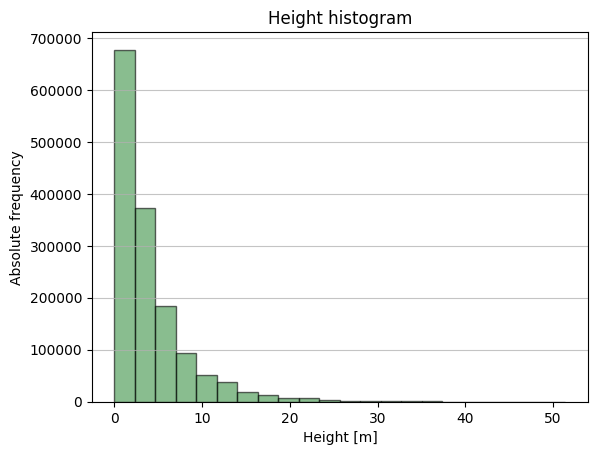

In [9]:
plt.figure()
plt.hist(data=gdf, #Dataframe
         x="Height (m)", #Random variable
         density = False, #Density line if desired, in this case is not
         bins="sturges", #Size of class interval
         color='#3a9144', #Fill colour for bars
         edgecolor='black', #Colour for bars' boundaries
         alpha= 0.6) #Transparency of bars
plt.grid(axis='y', alpha=0.75) #Grid for Y-Axis
plt.xlabel('Height [m]') #Label on X-Axis
plt.ylabel('Absolute frequency') #Label on Y-Axis
plt.title('Height histogram') #Title for the chart
plt.show() #Print the chart

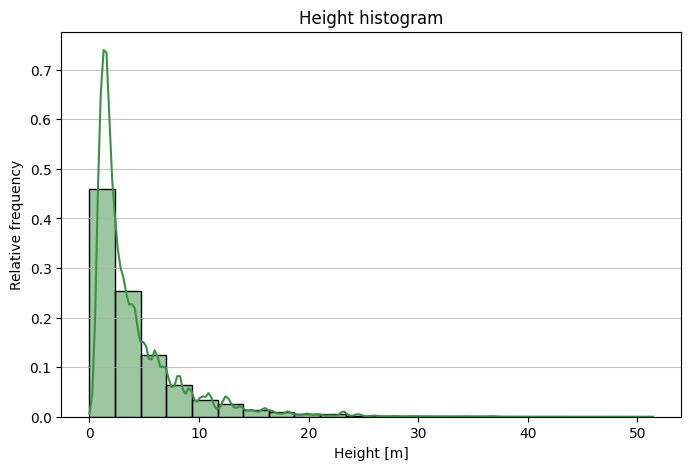

In [10]:
#Print the histogram
# Clean up any existing active figures
plt.figure(figsize=(8, 5))

# sns.histplot is an axes-level function and obeys standard matplotlib commands
sns.histplot(
    data=gdf,
    x="Height (m)",
    kde=True,
    bins="sturges",
    stat="probability",  # Makes the Y-axis represent relative frequency
    color='#3a9144', #Fill colour for bars
    edgecolor='black', #Colour for bars' boundaries
)

# Standard matplotlib modifiers work perfectly here
plt.grid(axis="y", alpha=0.75)
plt.xlabel("Height [m]")
plt.ylabel("Relative frequency")
plt.title("Height histogram")

plt.show()

The histogram confirms a strongly right-skewed, leptokurtic distribution (kurtosis = 10.83), with a sharp concentration of trees in the 1–3 m height class. This dominant peak suggests that a large proportion of the urban tree stock consists of young or recently planted individuals. The distribution decays rapidly after 5 m, with a long thin tail extending toward 50 m representing mature or exceptionally large specimens.

The dominance of short trees in Bogotá's Urapán population points to an urban forest that is predominantly young, with limited structural diversity in height. This has implications for canopy cover, ecosystem services such as shade provision and carbon storage, and long-term urban forest management planning.

In [11]:
# Filter the summary table where count is greater than or equal to 20000
ht_filtered = ht[ht['count'] >= 20000]

# Sort the filtered summary
ht_filtered = ht_filtered.sort_values('count', ascending=False)

# Sort the filtered summary
ht_filtered = ht_filtered.sort_values("count", ascending=False)

ht_filtered
ht_filtered.sort_values('count', ascending=False)

,count,mean,std,min,25%,50%,75%,max
Tree Name,,,,,,,,
Sauco,86550.0,3.518323,1.860710,0.300000,2.105565,3.364218,4.641151,26.027978
"Jazmin del cabo, laurel huesito",60892.0,4.624105,3.007968,0.128181,2.119715,4.026371,6.343297,23.159862
"Acacia negra, gris",55169.0,5.725071,4.236100,0.300000,2.133661,4.819760,8.222582,34.548488
"Chicala, chirlobirlo, flor amarillo",47352.0,3.596741,2.588167,0.300000,1.560000,2.881177,5.030205,26.027978
Holly liso,41782.0,3.142465,1.748928,0.300000,1.700000,2.734609,4.026371,29.691544
Eugenia,41332.0,4.677643,3.415930,0.300000,1.860523,3.777378,6.517530,24.512046
"Urapán, Fresno",41166.0,9.560743,7.291901,0.300000,3.168678,8.057055,14.781163,39.423761
Acacia japonesa,39414.0,6.801696,5.433762,0.300000,2.351807,5.286787,9.888033,37.162312
"Ciprés, Pino ciprés, Pino",38403.0,7.162833,5.619188,0.330000,2.688915,5.684140,9.987298,51.423665


/tmp/ipykernel_3700095/1225833352.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


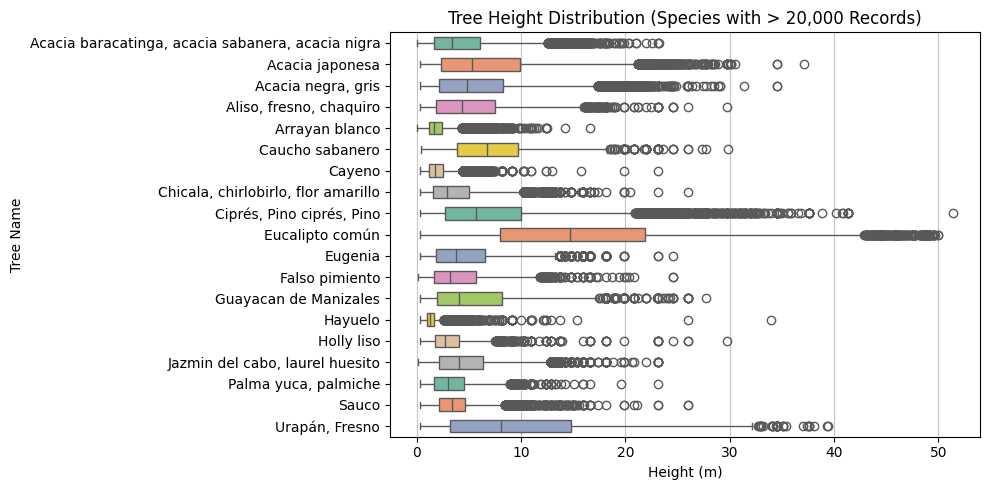

In [12]:
# 1. Count occurrences
tree_counts = gdf["Tree Name"].value_counts()
frequent_trees = tree_counts[tree_counts > 20000].index

# 2. Filter rows AND explicitly drop the empty categories
gdf_filtered = gdf[gdf["Tree Name"].isin(frequent_trees)].copy()

# ---> CRITICAL FIX FOR CATEGORICAL DATA <---
if hasattr(gdf_filtered["Tree Name"], "cat"):
    gdf_filtered["Tree Name"] = gdf_filtered["Tree Name"].cat.remove_unused_categories()
else:
    # If it's just regular text/object, convert to string to reset any weird formatting
    gdf_filtered["Tree Name"] = gdf_filtered["Tree Name"].astype(str)

# 3. Print the clean boxplot
plt.figure(figsize=(10, 5))  # Gives the plot some clean breathing room

sns.boxplot(
    data=gdf_filtered,
    y="Tree Name",
    x="Height (m)",
    width=0.6,
    showfliers=True,
    palette="Set2",
)

plt.title("Tree Height Distribution (Species with > 20,000 Records)", fontsize=12)
plt.xlabel("Height (m)")
plt.ylabel("Tree Name")
plt.grid(axis="x", alpha=0.75)
plt.tight_layout()

/tmp/ipykernel_3700095/2062011461.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


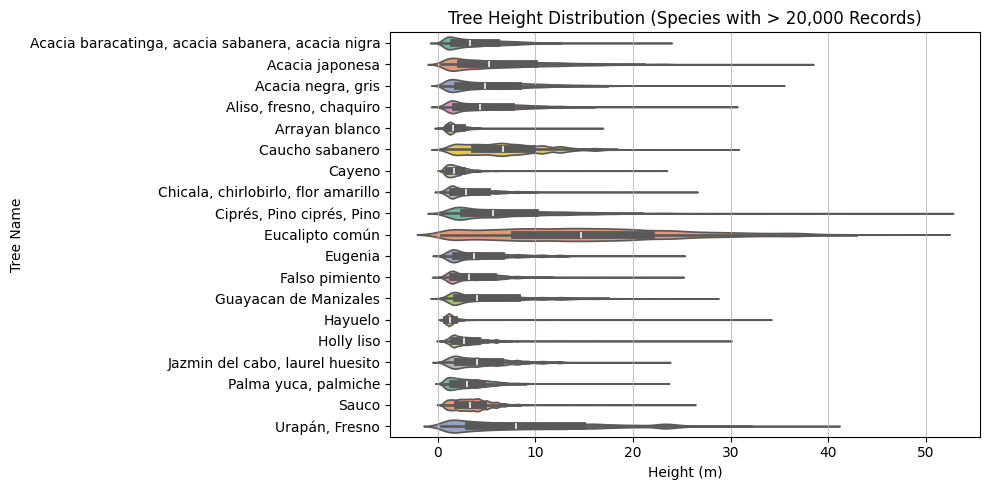

In [13]:
# 1. Count occurrences
tree_counts = gdf["Tree Name"].value_counts()
frequent_trees = tree_counts[tree_counts > 20000].index

# 2. Filter rows AND explicitly drop the empty categories
gdf_filtered = gdf[gdf["Tree Name"].isin(frequent_trees)].copy()

# ---> CRITICAL FIX FOR CATEGORICAL DATA <---
if hasattr(gdf_filtered["Tree Name"], "cat"):
    gdf_filtered["Tree Name"] = gdf_filtered["Tree Name"].cat.remove_unused_categories()
else:
    # If it's just regular text/object, convert to string to reset any weird formatting
    gdf_filtered["Tree Name"] = gdf_filtered["Tree Name"].astype(str)

# 3. Print the clean boxplot
plt.figure(figsize=(10, 5))  # Gives the plot some clean breathing room

sns.violinplot(
    data=gdf_filtered,
    y="Tree Name",
    x="Height (m)",
    width=0.6,
    palette="Set2",
)

plt.title("Tree Height Distribution (Species with > 20,000 Records)", fontsize=12)
plt.xlabel("Height (m)")
plt.ylabel("Tree Name")
plt.grid(axis="x", alpha=0.75)
plt.tight_layout()

The global dataset for urban trees comprises 1.473.580 records after cleaning, following the removal of three structural zero-value entries. As visualized in statistical analysis, Bogota's urban forest canopy exhibits a highly right-skewed ($\text{Skewness} = 2,74$) and leptokurtic ($\text{Kurtosis} = 10,83$) distribution. The median height of the city's total inventory stands at a modest 2.58 m, indicating that over half of the managed urban canopy consists of short understory individuals, young saplings, or shrubs. The mean height is pulled upward to 4.20 m ($\pm 4,37\text{ m}$) due to an extended tail of mature upper-canopy outliers that reach a maximum recorded height of 51,42 m. The Interquartile Range (IQR) shows that 50% of the entire urban forest infrastructure is tightly compressed between 1.50 m and 5,25 m.

In contrast to the heavily compressed global understory, *Fraxinus chinensis* (Urapán) forms a dominant structural pillar of Bogota's upper canopy. As demonstrated by the comparative boxplots and the density distributions in violinplots, the Urapán population is shifted significantly to the right of the global average. It exhibits a median height of approximately 8,0 m more than three times higher than the city-wide baseline. The broad, well-dispersed interquartile range (spanning roughly from 3,5 m to 14,5 m) and the wide horizontal distribution of its violin body indicate a highly mature, multi-aged adult population rather than a newly planted cohort.

#### 3.3.2 Data filtering

In [14]:
urapan_gdf = gdf[gdf["Tree Name"].isin(['Urapán, Fresno'])].copy()

urapan_gdf.head()

,geometry,GmlID,OBJECTID,Tree ID,Tree Name,Height (m),Emplacement,UPZ Code,Locality Code,Last Update,Latitude,Longitude,Emplacement System,Cadastral Sector Code,Land Use Type,Tree Species
4,POINT (4882886.212 2076399.986),Arbolado_Urbano.7202381,7202381,01010101000011,"Urapán, Fresno",12.395132,U3,UPZ16,01,2024-04-23 00:47:45,4.690652,-74.056349,4,008412,1,24
14,POINT (4882875.661 2076366.862),Arbolado_Urbano.7202391,7202391,01010101000024,"Urapán, Fresno",2.315362,H4,UPZ16,01,2005-10-28 00:00:00,4.690352,-74.056443,1,008412,1,24
15,POINT (4882872.789 2076333.029),Arbolado_Urbano.7202392,7202392,01010101000027,"Urapán, Fresno",2.402529,H4,UPZ16,01,2005-10-28 00:00:00,4.690046,-74.056469,1,008412,1,24
17,POINT (4882869.697 2076313.327),Arbolado_Urbano.7202394,7202394,01010101000029,"Urapán, Fresno",2.405628,H4,UPZ16,01,2005-10-28 00:00:00,4.689868,-74.056496,1,008412,1,24
18,POINT (4882869.014 2076309.642),Arbolado_Urbano.7202395,7202395,01010101000030,"Urapán, Fresno",2.405628,H4,UPZ16,01,2005-10-28 00:00:00,4.689835,-74.056502,1,008412,1,24


### 3.3.3 Tree height analysis for Urapán trees

The analysis for Urapán trees will be made in the same way as it was done before. 

In [15]:
ht_urapan =  urapan_gdf["Height (m)"]

# 1. Check how many zeros and nulls exist
print(f"Null values  : {ht_urapan.isna().sum():,}")
print(f"Zero values  : {(ht_urapan == 0).sum():,}")
print(f"Negative     : {(ht_urapan < 0).sum():,}")

# 2. Filter to realistic urban tree heights (0.5 m – 50 m)
ht_urapan_clean = ht_urapan[(ht_urapan > 0) & (ht_urapan <= 50)]
print(f"\nRecords kept : {len(ht_urapan_clean):,}  of  {len(ht_urapan):,}")

# 3. Clean stats
print("\n── Clean stats ──────────────────────────────")
print(f"Mean        : {ht_urapan_clean.mean():.2f} m")
print(f"Median      : {ht_urapan_clean.median():.2f} m")
print(f"Std Dev     : {ht_urapan_clean.std():.2f} m")
print(f"Min         : {ht_urapan_clean.min():.2f} m")
print(f"Max         : {ht_urapan_clean.max():.2f} m")
print(f"25th pct    : {ht_urapan_clean.quantile(0.25):.2f} m")
print(f"75th pct    : {ht_urapan_clean.quantile(0.75):.2f} m")
print(f"IQR         : {(ht_urapan_clean.quantile(0.75) - ht_urapan_clean.quantile(0.25)):.2f} m")
print(f"Skewness    : {ht_urapan_clean.skew():.2f}")
print(f"Kurtosis    : {ht_urapan_clean.kurt():.2f}")

Null values  : 0
Zero values  : 0
Negative     : 0

Records kept : 41,166  of  41,166

── Clean stats ──────────────────────────────
Mean        : 9.56 m
Median      : 8.06 m
Std Dev     : 7.29 m
Min         : 0.30 m
Max         : 39.42 m
25th pct    : 3.17 m
75th pct    : 14.78 m
IQR         : 11.61 m
Skewness    : 0.68
Kurtosis    : -0.55


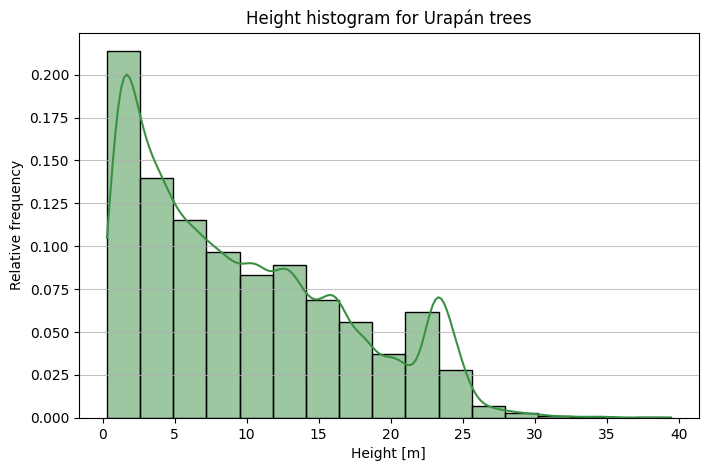

In [16]:
#Print the histogram
# Clean up any existing active figures
plt.figure(figsize=(8, 5))

# sns.histplot is an axes-level function and obeys standard matplotlib commands
sns.histplot(
    data=urapan_gdf,
    x="Height (m)",
    kde=True,
    bins="sturges",
    stat="probability",  # Makes the Y-axis represent relative frequency
    color='#3a9144', #Fill colour for bars
    edgecolor='black', #Colour for bars' boundaries
)

# Standard matplotlib modifiers work perfectly here
plt.grid(axis="y", alpha=0.75)
plt.xlabel("Height [m]")
plt.ylabel("Relative frequency")
plt.title("Height histogram for Urapán trees")

plt.show()

Text(0.5, 1.0, 'Height boxplot for Urapán trees')

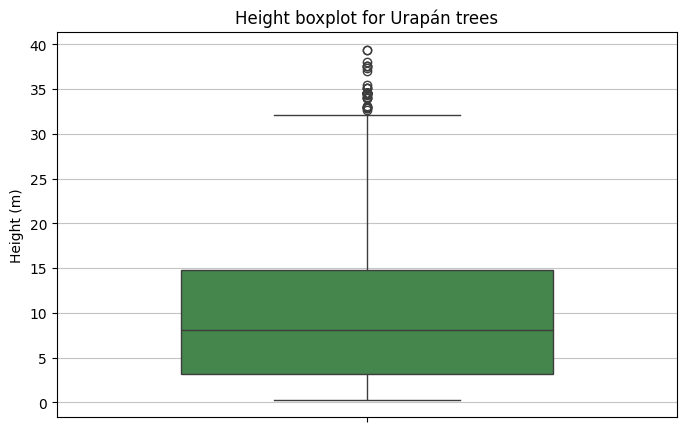

In [17]:
plt.figure(figsize=(8, 5))  # Gives the plot some clean breathing room
sns.boxplot(
    data=urapan_gdf,
    y="Height (m)",
    width=0.6,
    showfliers=True,
    color='#3a9144', #Fill colour for bars,
)
plt.grid(axis="y", alpha=0.75)
plt.title("Height boxplot for Urapán trees")

Text(0.5, 1.0, 'Height violinplot for Urapán trees')

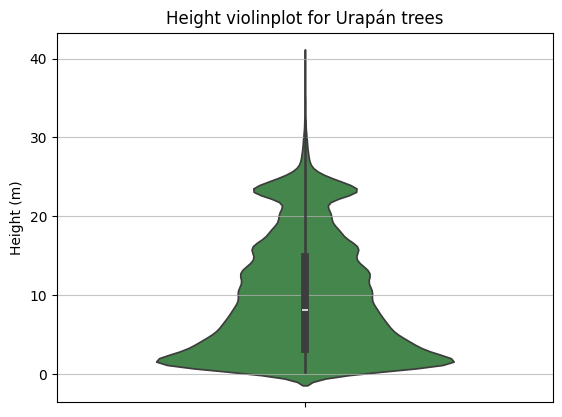

In [18]:
sns.violinplot(
    data=urapan_gdf,
    y="Height (m)",
    width=0.6,
    color='#3a9144', #Fill colour for bars,
)
plt.grid(axis="y", alpha=0.75)
plt.title("Height violinplot for Urapán trees")

Based on statistical calculations and histogram made for height, the isolated dataset for Bogota's *Fraxinus chinensis* (Urapán) comprises 41,280 valid records with no missing, zero, or negative entries. Unlike the heavily right-skewed global city inventory, the Urapán population displays a more structurally mature and balanced architecture, characterized by a mild positive skewness of 0.68 and a negative kurtosis of -0.54. The probability density curve and the distinct contours of the violin plot reveal a multimodal configuration with notable structural peaks around 2 m, 13 m, and 23 m. This clear segmentation suggests a multi-aged population distribution resulting from distinct historical planting cycles in the city's urban development.

The central tendency and structural dispersion parameters confirm that the species forms a dominant vertical pillar in the city's landscape. The population exhibits a median height of 8,06 m and a mean height of 9,56 m ($\pm$ 7,29 m standard deviation), stretching from a minimum sapling stage of 0,30 m to a maximum canopy height of 39,42 m. A broad Interquartile Range (IQR) of 11,61 m—spanning from the 25th percentile at 3,17 m to the 75th percentile at 14,78 m—demonstrates that the central 50% of these trees are actively functioning across both the mid-canopy and upper-stratum layers. Additionally, a distinct cluster of upper-canopy outliers is visible between 32 m and 40 m, representing the legacy, old-growth individuals that define the historic vertical limit of the species in Bogotá.

### 3.4 Tree distribution according to administrative boundaries

#### 3.4.1 Tree count per locality

In [19]:
tree_count_df = (
    urapan_gdf.groupby("Locality Code")
    .size()
    .reset_index(name="Tree Count")
    .sort_values("Tree Count", ascending=False)
    .reset_index(drop=True)
)

#Join data
tree_bound = loc_wgs84.merge(tree_count_df, left_on="Code", right_on="Locality Code", how="left")

#Stem density calculation
tree_bound["Density"] = tree_bound["Tree Count"] / tree_bound["Area (ha)"]
tree_bound.head()

/tmp/ipykernel_3700095/2272106163.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  urapan_gdf.groupby("Locality Code")


,Name,Declaration Ammendment,Area (ha),Code,SHAPE_Leng,SHAPE_Area,geometry,Locality Code,Tree Count,Density
0,ANTONIO NARIÑO,Acuerdo 117 de 2003,486.965,15,0.108973,0.000397,"MULTIPOLYGON (((-74.13075 4.59335, -74.12917 4...",15,860.0,1.766041
1,TUNJUELITO,Acuerdo 117 de 2003,989.107,06,0.210542,0.000807,"MULTIPOLYGON (((-74.13777 4.59489, -74.13165 4...",06,990.0,1.000903
2,RAFAEL URIBE URIBE,Acuerdo 117 de 2003,1380.613,18,0.174513,0.001126,"MULTIPOLYGON (((-74.12803 4.59254, -74.12777 4...",18,1341.0,0.971308
3,CANDELARIA,Acuerdo 117 de 2003,205.602,17,0.067158,0.000168,"MULTIPOLYGON (((-74.06621 4.60317, -74.0662 4....",17,448.0,2.178967
4,BARRIOS UNIDOS,Acuerdo 8 de 1977,1187.907,12,0.121180,0.000969,"MULTIPOLYGON (((-74.05725 4.68684, -74.06249 4...",12,2928.0,2.464839


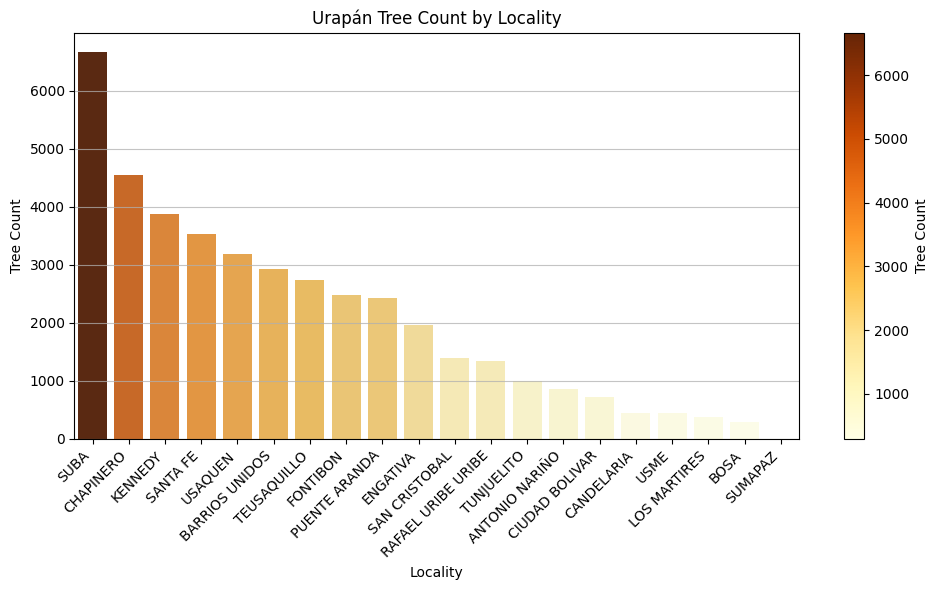

In [20]:
sorted_df = tree_bound.sort_values("Tree Count", ascending=False).reset_index(drop=True)
n         = len(sorted_df)

# ── Normalise against actual Tree Count values, not rank index ──
cmap   = plt.get_cmap("YlOrBr")
norm   = mcolors.Normalize(
    vmin=sorted_df["Tree Count"].min(),   # ← actual min value
    vmax=sorted_df["Tree Count"].max()    # ← actual max value
)
colors = [mcolors.to_hex(cmap(norm(v))) for v in sorted_df["Tree Count"]]  # ← map each bar to its real value

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=sorted_df,
    x="Name",
    y="Tree Count",
    palette=colors,
    hue="Name",
    legend=False
)

# Colorbar now matches — same norm and cmap as the bars
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Tree Count")

plt.xticks(rotation=45, ha="right")
plt.title("Urapán Tree Count by Locality")
plt.grid(axis="y", alpha=0.75)
plt.xlabel("Locality")
plt.ylabel("Tree Count")
plt.tight_layout()
plt.show()

Tree count chart reveals a stark spatial imbalance in the distribution of *Fraxinus chinensis* across Bogota. The northwestern locality of Suba is the absolute epicenter of the population, hosting nearly 6,700 trees, followed by a high-density cluster in northern and central sectors such as Chapinero, Kennedy, Santa Fe, and Usaquén. Conversely, the species becomes increasingly sparse in the southern localities and falls to zero in the rural expanse of Sumapaz. This high geographic concentration implies that any localized phytosanitary threats from pests or high airborne allergen loads will disproportionately impact the ecological stability and public health of the city's northern and core urban zones.

#### 3.4.2 Density

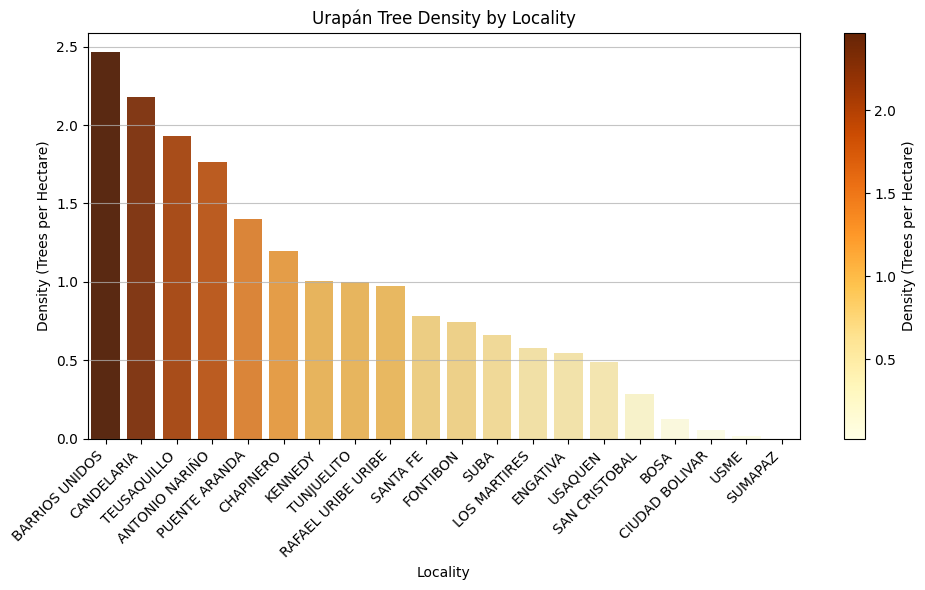

In [21]:
sorted_df = tree_bound.sort_values("Density", ascending=False).reset_index(drop=True)

# ── Normalise against actual Density values ──
cmap   = plt.get_cmap("YlOrBr")
norm   = mcolors.Normalize(
    vmin=sorted_df["Density"].min(),   # ← actual min
    vmax=sorted_df["Density"].max()    # ← actual max
)
colors = [mcolors.to_hex(cmap(norm(v))) for v in sorted_df["Density"]]  # ← map each bar to its real density

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=sorted_df,
    x="Name",
    y="Density",
    palette=colors,
    hue="Name",       # ← required for seaborn ≥ 0.13
    legend=False
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Density (Trees per Hectare)")

plt.xticks(rotation=45, ha="right")
plt.title("Urapán Tree Density by Locality")
plt.grid(axis="y", alpha=0.75)
plt.xlabel("Locality")
plt.ylabel("Density (Trees per Hectare)")
plt.tight_layout()
plt.show()

The tree density chart shifts the analytical focus from raw population volume to spatial concentration, mapping Urapán tree density (trees per hectare) across Bogota's localities. This metric drastically alters the geographic landscape seen previously: while Suba dominated in absolute tree counts, it drops significantly in density due to its massive territorial area. Instead, the historical central-urban core emerges as the true ecological pressure zone, led by Barrios Unidos with the highest density at nearly 2,5 trees/ha, followed closely by Candelaria (~2,2 trees/ha), Teusaquillo (~1,9 trees/ha), and Antonio Nariño (~1,8 trees/ha). Conversely, large peripheral or rural localities like Ciudad Bolívar, Usme, and Sumapaz display near-zero densities. For the research proposal, this implies that while northern zones have more total hosts, the compact urban fabrics of the central localities face the most intense, hyper-concentrated micro-environmental impacts from pest colonization and airborne allergens.

### 3.5 Point pattern analysis

#### 3.5.1 Mean distance

In [22]:
# Extract XY coordinates in your projected metric system (EPSG:9377) 
# Projected coordinates are required for accurate metric distance calculations
points_metric = list(zip(urapan_gdf.geometry.x, urapan_gdf.geometry.y))

# Calculate the Nearest Neighbor Distance for each tree point
tree = cKDTree(points_metric)
distances, _ = tree.query(points_metric, k=2)

# The first column is distance to self (zero), the second column is the nearest neighbor
nnd = distances[:, 1]

print(f"Mean Nearest Neighbor Distance: {nnd.mean():.2f} meters")
# An exceptionally low mean distance relative to the study area size 
# indicates highly concentrated clustering (hotspots).

Mean Nearest Neighbor Distance: 14.20 meters


In [23]:
# Calculate mean distance for each Locality Code
locality_distances = (
    urapan_gdf.groupby("Locality Code")
    .apply(lambda group: cKDTree(list(zip(group.geometry.x, group.geometry.y))).query(list(zip(group.geometry.x, group.geometry.y)), k=2)[0][:, 1].mean())
    .reset_index(name="Mean NND")
)

locality_distances.head()

/tmp/ipykernel_3700095/4191515177.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  urapan_gdf.groupby("Locality Code")
/tmp/ipykernel_3700095/4191515177.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: cKDTree(list(zip(group.geometry.x, group.geometry.y))).query(list(zip(group.geometry.x, group.geometry.y)), k=2)[0][:, 1].mean())


,Locality Code,Mean NND
0,01,15.512655
1,02,8.779690
2,03,5.541840
3,04,17.073275
4,05,33.879288


In [24]:
tree_nnd = tree_bound.merge(locality_distances, left_on="Code", right_on="Locality Code", how="left")
tree_nnd.head()

,Name,Declaration Ammendment,Area (ha),Code,SHAPE_Leng,SHAPE_Area,geometry,Locality Code_x,Tree Count,Density,Locality Code_y,Mean NND
0,ANTONIO NARIÑO,Acuerdo 117 de 2003,486.965,15,0.108973,0.000397,"MULTIPOLYGON (((-74.13075 4.59335, -74.12917 4...",15,860.0,1.766041,15,14.366575
1,TUNJUELITO,Acuerdo 117 de 2003,989.107,06,0.210542,0.000807,"MULTIPOLYGON (((-74.13777 4.59489, -74.13165 4...",06,990.0,1.000903,06,15.875281
2,RAFAEL URIBE URIBE,Acuerdo 117 de 2003,1380.613,18,0.174513,0.001126,"MULTIPOLYGON (((-74.12803 4.59254, -74.12777 4...",18,1341.0,0.971308,18,17.956926
3,CANDELARIA,Acuerdo 117 de 2003,205.602,17,0.067158,0.000168,"MULTIPOLYGON (((-74.06621 4.60317, -74.0662 4....",17,448.0,2.178967,17,5.697434
4,BARRIOS UNIDOS,Acuerdo 8 de 1977,1187.907,12,0.121180,0.000969,"MULTIPOLYGON (((-74.05725 4.68684, -74.06249 4...",12,2928.0,2.464839,12,9.035051


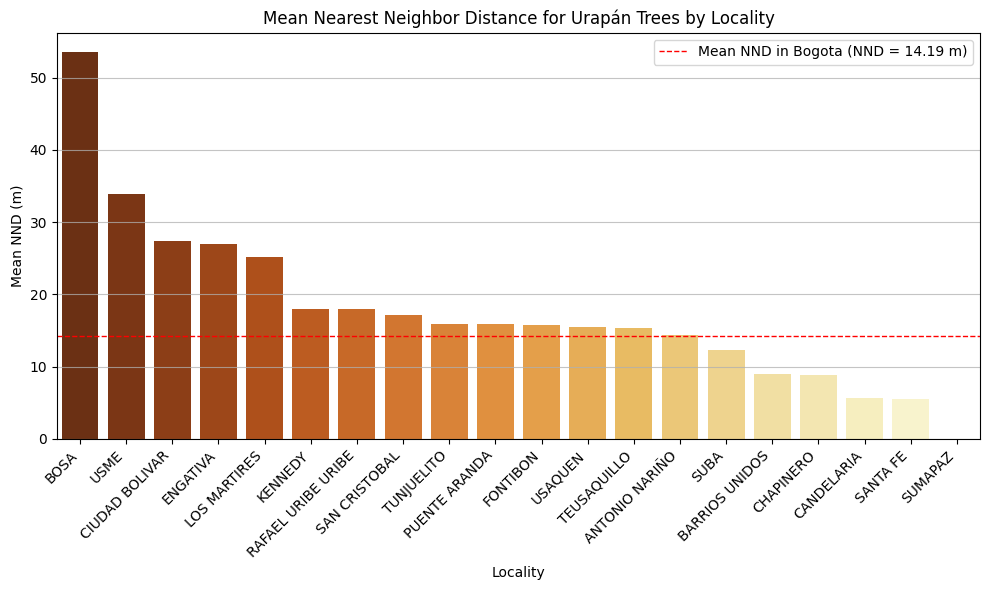

In [25]:
# Generate the chart for NND
plt.figure(figsize=(10, 6))

# Capture the Axes object (ax) from the Seaborn barplot
ax = sns.barplot(
    data=tree_nnd.sort_values("Mean NND", ascending=False),
    x="Name",
    y="Mean NND",
    palette="YlOrBr_r",
    hue="Name",
    legend=False
)

# ── Reference line ────────────────────────────────────────────
# The ax object is now defined, and the label typo is fixed (14.19 m)
ax.axhline(y=14.19, color="red", linestyle="--", linewidth=1, label="Mean NND in Bogota (NND = 14.19 m)")
ax.legend()

plt.xticks(rotation=45, ha="right")
plt.title("Mean Nearest Neighbor Distance for Urapán Trees by Locality")
plt.grid(axis="y", alpha=0.75)
plt.xlabel("Locality")
plt.ylabel("Mean NND (m)")
plt.tight_layout()

plt.show()

Previous chart analyzes the spatial dispersion of *Fraxinus chinensis* by illustrating the Mean Nearest Neighbor Distance (NND) across Bogota's localities relative to a city-wide average of 14.19 meters. Southern and peripheral localities like Bosa (~53 m) and Usme (~34 m) exhibit exceptionally high NND values, confirming that their sparse Urapán populations are highly isolated and fragmented. Conversely, traditional high-density and central urban sectors—such as Barrios Unidos, Chapinero, Candelaria, and Santa Fe—fall well below the reference line with mean distances between 5 and 9 meters, indicating tightly clustered, contiguous tree stands. For your phytosanitary pipeline, this reveals that while the southern peripheries act as natural spatial barriers that could hinder the progression of *Tropidosteptes chapingoensis*, the dense, low-NND configurations of the central and northern cores create highly vulnerable vectors for rapid, continuous pest transmission.

#### 3.5.2 Nearest Neighbour Index

In [26]:
results = []

for locality in urapan_gdf["Locality Code"].unique():
    subset = urapan_gdf[urapan_gdf["Locality Code"] == locality].copy()
    n = len(subset)
    if n < 2:
        continue

    # Reproject to MAGNA for distances in metres
    subset_m = subset.to_crs(epsg=9377)
    coords = np.array([(geom.x, geom.y) for geom in subset_m.geometry])

    # Nearest neighbour observed mean distance
    kdtree = cKDTree(coords)
    dists, _ = kdtree.query(coords, k=2)
    observed_mean = dists[:, 1].mean()

    # ── Use official Area (ha) from the localities layer ──────
    area_ha = tree_bound.loc[tree_bound["Code"] == locality, "Area (ha)"].values[0]
    area_m2 = area_ha * 10000          # convert ha → m²

    expected_mean = 0.5 / np.sqrt(n / area_m2)
    nni = observed_mean / expected_mean

    results.append({
        "Locality"      : locality,
        "Tree Count"    : n,
        "Area (ha)"     : round(area_ha, 3),       # ← official area
        "Observed_dist" : round(observed_mean, 2),
        "Expected_dist" : round(expected_mean, 2),
        "NNI"           : round(nni, 4),
        "Pattern"       : "Clustered" if nni < 1 else ("Dispersed" if nni > 1 else "Random")
    })

nni_df = pd.DataFrame(results).sort_values("NNI", ascending=False)
print(nni_df.to_string(index=False))

#Join data
loc_ppt_data = tree_nnd.merge(nni_df, left_on="Code", right_on="Locality", how="left")

# Drop columns
loc_ppt_data.drop(columns=["Locality Code_y", "Area (ha)_y", "Tree Count_y","Locality"], inplace=True)

# Rename columns for better presentation in PowerPoint
loc_ppt_data.rename(columns={"Area (ha)_x": "Area (ha)",
                           "Observed_dist": "Observed Distance (m)",
                           "Expected_dist": "Expected Distance (m)",
                           "NNI": "Nearest Neighbor Index",
                           "Mean NND": "Mean Nearest Neighbor Distance (m)",
                           "Tree Count_x": "Tree Count",
                           "Locality Code_x": "Locality Code",
                           "Pattern_x": "Pattern",
                           }, inplace=True
                  )

# Convert data types for better memory usage and analysis
loc_ppt_data = loc_ppt_data.astype({
    "Pattern": pd.CategoricalDtype(ordered=False),
    "Code": pd.CategoricalDtype(ordered=False),
    "Name": pd.CategoricalDtype(ordered=False),
    "Area (ha)": pd.Float64Dtype(),
    "Observed Distance (m)": pd.Float64Dtype(),
    "Expected Distance (m)": pd.Float64Dtype(),
    "Nearest Neighbor Index": pd.Float64Dtype(),
    "Mean Nearest Neighbor Distance (m)": pd.Float64Dtype(),
    "Tree Count": pd.Int64Dtype(),
})

# Delete duplicated columns
loc_ppt_data = loc_ppt_data.loc[:, ~loc_ppt_data.columns.duplicated()]

loc_ppt_data["Density"] = loc_ppt_data["Tree Count"] / loc_ppt_data["Area (ha)"]

loc_ppt_data.head()

Locality  Tree Count  Area (ha)  Observed_dist  Expected_dist    NNI   Pattern
      13        2732   1416.421          15.34          36.00 0.4262 Clustered
      10        1953   3580.845          26.95          67.70 0.3981 Clustered
      14         378    650.076          25.22          65.57 0.3846 Clustered
      15         860    486.965          14.37          37.62 0.3818 Clustered
      07         295   2388.619          53.55         142.28 0.3764 Clustered
      16        2418   1727.615          15.85          42.26 0.3751 Clustered
      08        3869   3851.281          17.96          49.89 0.3600 Clustered
      18        1341   1380.613          17.96          50.73 0.3539 Clustered
      06         990    989.107          15.88          49.98 0.3176 Clustered
      12        2928   1187.907           9.04          31.85 0.2837 Clustered
      09        2481   3321.438          15.73          57.85 0.2720 Clustered
      01        3184   6506.570          15.51      

,Name,Declaration Ammendment,Area (ha),Code,SHAPE_Leng,SHAPE_Area,geometry,Locality Code,Tree Count,Density,Mean Nearest Neighbor Distance (m),Observed Distance (m),Expected Distance (m),Nearest Neighbor Index,Pattern
0,ANTONIO NARIÑO,Acuerdo 117 de 2003,486.965,15,0.108973,0.000397,"MULTIPOLYGON (((-74.13075 4.59335, -74.12917 4...",15,860,1.766041,14.366575,14.37,37.62,0.3818,Clustered
1,TUNJUELITO,Acuerdo 117 de 2003,989.107,06,0.210542,0.000807,"MULTIPOLYGON (((-74.13777 4.59489, -74.13165 4...",06,990,1.000903,15.875281,15.88,49.98,0.3176,Clustered
2,RAFAEL URIBE URIBE,Acuerdo 117 de 2003,1380.613,18,0.174513,0.001126,"MULTIPOLYGON (((-74.12803 4.59254, -74.12777 4...",18,1341,0.971308,17.956926,17.96,50.73,0.3539,Clustered
3,CANDELARIA,Acuerdo 117 de 2003,205.602,17,0.067158,0.000168,"MULTIPOLYGON (((-74.06621 4.60317, -74.0662 4....",17,448,2.178967,5.697434,5.7,33.87,0.1682,Clustered
4,BARRIOS UNIDOS,Acuerdo 8 de 1977,1187.907,12,0.121180,0.000969,"MULTIPOLYGON (((-74.05725 4.68684, -74.06249 4...",12,2928,2.464839,9.035051,9.04,31.85,0.2837,Clustered


/tmp/ipykernel_3700095/2727010420.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


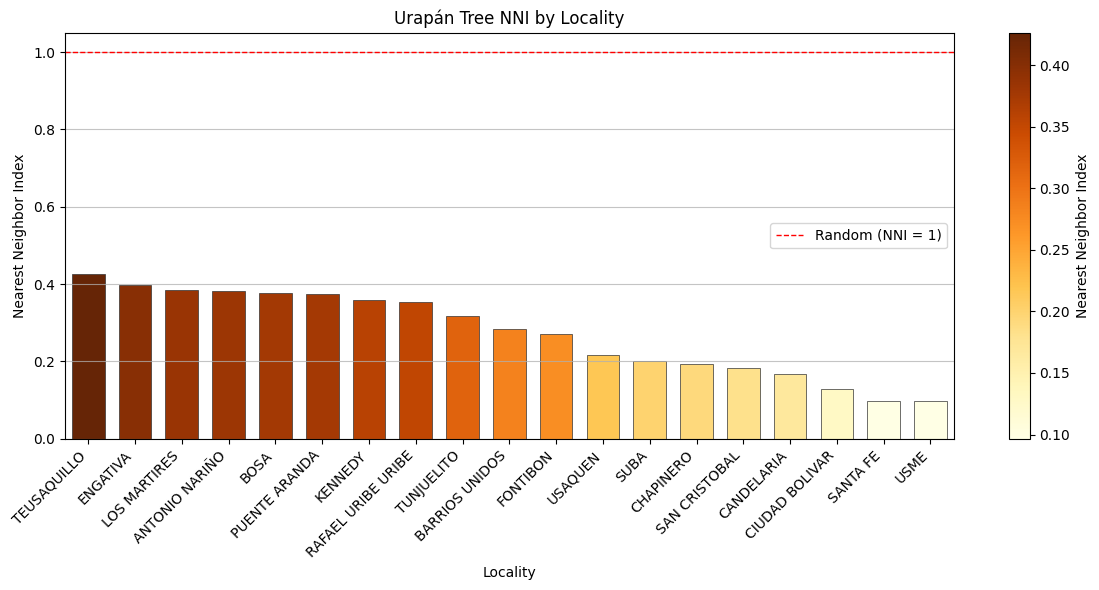

In [27]:
NNI_COL  = "Nearest Neighbor Index"
NAME_COL = "Name"

sorted_df = (
    loc_ppt_data[[NAME_COL, NNI_COL]]
    .dropna(subset=[NNI_COL])
    .sort_values(NNI_COL, ascending=False)
    .reset_index(drop=True)
)

cmap  = plt.get_cmap("YlOrBr")
norm  = mcolors.Normalize(
    vmin=sorted_df[NNI_COL].min(),
    vmax=sorted_df[NNI_COL].max()
)

fig, ax = plt.subplots(figsize=(12, 6))

# ── Draw bars ─────────────────────────────────────────────────
sns.barplot(
    data=sorted_df,
    x=NAME_COL,
    y=NNI_COL,
    order=sorted_df[NAME_COL],   # ← fix 1: enforce sort order
    color="steelblue",
    width=0.7,                   # ← fix 2: wider bars (0.0–1.0)
    ax=ax
)

# ── Recolour bars by NNI value ────────────────────────────────
for bar, nni_val in zip(ax.patches, sorted_df[NNI_COL]):
    bar.set_facecolor(cmap(norm(nni_val)))
    bar.set_edgecolor("#333333")
    bar.set_linewidth(0.5)

# ── Reference line ────────────────────────────────────────────
ax.axhline(y=1, color="red", linestyle="--", linewidth=1, label="Random (NNI = 1)")
ax.legend()

# ── Colorbar ──────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Nearest Neighbor Index")

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_title("Urapán Tree NNI by Locality")
ax.grid(axis="y", alpha=0.75)
ax.set_xlabel("Locality")
ax.set_ylabel("Nearest Neighbor Index")
plt.tight_layout()
plt.show()

On previpus analysis, the spatial clustering intensity of *Fraxinus chinensis* was mapped by illustrating the Nearest Neighbor Index (NNI) across Bogota's localities relative to a theoretical random distribution ($\text{NNI} = 1$). Across all sampled administrative divisions, the NNI values drop drastically below the reference line, ranging between approximately 0,10 and 0,43. This structural pattern empirically proves that the city's Urapán population is strongly and significantly clustered rather than randomly dispersed. The spatial clustering is most extreme ($\text{NNI} \approx 0,10$) in localities such as Santa Fe, Usme, and Ciudad Bolívar, indicating highly concentrated localized pockets of the species. Even in the least clustered sector, Teusaquillo ($\text{NNI} \approx 0,43$), the index indicates a highly constrained, non-random distribution. For the research proposal, this near-universal clustering behavior underscores a high landscape vulnerability: the proximity of individuals within these tight clusters eliminates spatial buffering, creating ideal continuous vectors for rapid pest colonization by *Tropidosteptes* chapingoensis and generating intense, localized hot zones of airborne pollen.

### 3.6. Map export

For internal analysis and aiming on providing narrowed datasets for spatial analysis and modelling by the usage of other formats in different tools suitable for users of different levels, knowledge and experience, datasets are exported in formats like GeoJSON, TIFF (in case of raster data) and HTML interactive maps.

#### 3.6.1 GeoJSON for external mapping

In [28]:
# ─────────────────── Exporting Urapán Height maps ────────────────────────────────────────── 
# ── Find and convert Timestamp columns to string ─────────────
urapan_export = urapan_gdf.copy()

timestamp_cols = urapan_export.select_dtypes(include=["datetime64", "datetimetz"]).columns.tolist()
print(f"Timestamp columns found: {timestamp_cols}")

for col in timestamp_cols:
    urapan_export[col] = urapan_export[col].astype(str)

# ── Export ────────────────────────────────────────────────────
urapan_export.to_file("../geojson/urapan_trees.geojson", driver="GeoJSON")
print("✓ Saved → ../geojson/urapan_trees.geojson")

Timestamp columns found: ['Last Update']
✓ Saved → ../geojson/urapan_trees.geojson


In [29]:
# ─────────────────── Exporting Localities Maps ────────────────────────────────────────── 
# Use tree_bound if available, otherwise fall back to loc_wgs84
try:
    loc_export = loc_ppt_data.copy()
except NameError:
    loc_export = loc_ppt_data.copy()

# ── Export ────────────────────────────────────────────────────
loc_export.to_file("../geojson/localities.geojson", driver="GeoJSON")
print("✓ Saved → ../geojson/localities.geojson")

✓ Saved → ../geojson/localities.geojson


As a result of GeoJSON files export, map layout were generated derived from this new datasets. These layouts were generated in QGIS.

![TreeHeight](../img/Height3.jpeg)

Figure 4. Tree height map for Urapán trees.

![TreeCount](../img/TreeCount.jpeg)

Figure 5. Tree Count per Locality.

![TreeDensity](../img/Density.jpeg)

Figure 6. Tree density for Bogota localities.

![NND](../img/NND.jpeg)

Figure 7. Mean NND map per locality.

![NNI](../img/NNI.jpeg)

Figure 8. NNI map per locality.

#### 3.6.2 Raster export for external mapping

In [30]:
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────
# PATHS
# ─────────────────────────────────────────────────────────────
GEOJSON_IN  = "/home/miguel.salamanca/bogota_urapan_analysis/geojson/urapan_trees.geojson"
RASTER_OUT  = "/home/miguel.salamanca/bogota_urapan_analysis/tif/urapan_kde_density.tif"

os.makedirs(os.path.dirname(RASTER_OUT), exist_ok=True)

# ─────────────────────────────────────────────────────────────
# KDE PARAMETERS  — tune these to your needs
# ─────────────────────────────────────────────────────────────
RESOLUTION  = 50      # cell size in metres  (50 m = fine detail)
BANDWIDTH   = 300     # smoothing radius in metres
NODATA      = 0       # value for empty cells (0 = no trees, but adjust if needed)

print("=" * 60)
print("  Urapán KDE Density Raster")
print("=" * 60)
print(f"\n  Resolution : {RESOLUTION} m")
print(f"  Bandwidth  : {BANDWIDTH} m")

# ─────────────────────────────────────────────────────────────
# 1. LOAD & REPROJECT TO MAGNA (metres)
# ─────────────────────────────────────────────────────────────
print("\n[1] Loading points ...")
gdf = gpd.read_file(GEOJSON_IN)
print(f"    Records : {len(gdf):,}  |  CRS: {gdf.crs}")

gdf_m = gdf[gdf.geometry.notnull()].to_crs(epsg=9377)
coords = np.array([[g.x, g.y] for g in gdf_m.geometry])
x, y   = coords[:, 0], coords[:, 1]
print(f"    Valid points : {len(x):,}")

# ─────────────────────────────────────────────────────────────
# 2. DEFINE RASTER GRID
# ─────────────────────────────────────────────────────────────
print("\n[2] Defining grid ...")

margin  = BANDWIDTH * 3
x_min   = x.min() - margin
x_max   = x.max() + margin
y_min   = y.min() - margin
y_max   = y.max() + margin

n_cols  = int(np.ceil((x_max - x_min) / RESOLUTION))
n_rows  = int(np.ceil((y_max - y_min) / RESOLUTION))

# Snap extent to resolution
x_max   = x_min + n_cols * RESOLUTION
y_max   = y_min + n_rows * RESOLUTION

print(f"    Extent  : ({x_min:.0f}, {y_min:.0f}) -> ({x_max:.0f}, {y_max:.0f})")
print(f"    Grid    : {n_cols} cols x {n_rows} rows")
print(f"    Cells   : {n_cols * n_rows:,}")

# Cell centre coordinates — top-down row order
xi = x_min + (np.arange(n_cols) + 0.5) * RESOLUTION
yi = y_max - (np.arange(n_rows) + 0.5) * RESOLUTION
xx, yy      = np.meshgrid(xi, yi)
grid_coords = np.vstack([xx.ravel(), yy.ravel()])

# ─────────────────────────────────────────────────────────────
# 3. KDE — density in trees / m²
# ─────────────────────────────────────────────────────────────
print("\n[3] Computing KDE ...")

bw_method    = BANDWIDTH / np.std(coords, axis=0).mean()
kde          = gaussian_kde(coords.T, bw_method=bw_method)

# Evaluate in chunks to avoid memory issues on large datasets
CHUNK        = 500_000
n_cells      = grid_coords.shape[1]
density_flat = np.empty(n_cells, dtype=np.float32)

for start in range(0, n_cells, CHUNK):
    end = min(start + CHUNK, n_cells)
    density_flat[start:end] = kde(grid_coords[:, start:end])
    print(f"    {end / n_cells * 100:5.1f}%  ({end:,} / {n_cells:,} cells)", end="\r")

print(f"\n    KDE complete")

# Reshape and convert probability density -> trees / m²
density        = density_flat.reshape(n_rows, n_cols)
density_per_m2 = (density * len(x)).astype(np.float32)

print(f"    Density range : {density_per_m2.min():.8f} – {density_per_m2.max():.6f} trees/m2")
print(f"    Peak density  : {density_per_m2.max() * 10000:.1f} trees/ha")

# ─────────────────────────────────────────────────────────────
# 4. EXPORT GEOTIFF
# ─────────────────────────────────────────────────────────────
print(f"\n[4] Writing GeoTIFF -> {RASTER_OUT}")

transform = from_origin(x_min, y_max, RESOLUTION, RESOLUTION)

with rasterio.open(
    RASTER_OUT,
    mode       = "w",
    driver     = "GTiff",
    height     = n_rows,
    width      = n_cols,
    count      = 1,
    dtype      = rasterio.float32,
    crs        = CRS.from_epsg(9377),
    transform  = transform,
    nodata     = NODATA,
    compress   = "lzw",
    tiled      = True,
    blockxsize = 256,
    blockysize = 256,
) as dst:
    dst.write(density_per_m2, 1)
    dst.update_tags(
        1,
        DESCRIPTION  = "Urapan tree density - KDE",
        UNITS        = "trees per m2",
        BANDWIDTH_M  = str(BANDWIDTH),
        RESOLUTION_M = str(RESOLUTION),
        N_TREES      = str(len(x)),
    )

print("    GeoTIFF saved")

# ─────────────────────────────────────────────────────────────
# 5. VERIFY
# ─────────────────────────────────────────────────────────────
print("\n[5] Verifying output ...")
with rasterio.open(RASTER_OUT) as src:
    print(f"    CRS       : {src.crs}")
    print(f"    Transform : {src.transform}")
    print(f"    Shape     : {src.height} rows x {src.width} cols")
    print(f"    Dtype     : {src.dtypes[0]}")
    data  = src.read(1)
    valid = data[data != NODATA]
    print(f"    Min value : {valid.min():.8f} trees/m2")
    print(f"    Max value : {valid.max():.6f} trees/m2")
    print(f"    Max in ha : {valid.max() * 10000:.2f} trees/ha")

print("\n" + "=" * 60)
print("  Done!")
print(f"\n  Output : {RASTER_OUT}")
print("=" * 60)

  Urapán KDE Density Raster

  Resolution : 50 m
  Bandwidth  : 300 m

[1] Loading points ...
    Records : 41,166  |  CRS: EPSG:9377
    Valid points : 41,166

[2] Defining grid ...
    Extent  : (4864115, 2051089) -> (4888465, 2091589)
    Grid    : 487 cols x 810 rows
    Cells   : 394,470

[3] Computing KDE ...


    100.0%  (394,470 / 394,470 cells)
    KDE complete
    Density range : 0.00000000 – 0.006449 trees/m2
    Peak density  : 64.5 trees/ha

[4] Writing GeoTIFF -> /home/miguel.salamanca/bogota_urapan_analysis/tif/urapan_kde_density.tif
    GeoTIFF saved

[5] Verifying output ...
    CRS       : EPSG:9377
    Transform : | 50.00, 0.00, 4864114.74|
| 0.00,-50.00, 2091588.66|
| 0.00, 0.00, 1.00|
    Shape     : 810 rows x 487 cols
    Dtype     : float32
    Min value : 0.00000000 trees/m2
    Max value : 0.006449 trees/m2
    Max in ha : 64.49 trees/ha

  Done!

  Output : /home/miguel.salamanca/bogota_urapan_analysis/tif/urapan_kde_density.tif


![KDE](../img/KDE.jpeg)

Figure 9. Kernel Density Estimation map made for Urapán trees.

#### 3.6.3 HTML maps

In [31]:
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────
# PATH
# ─────────────────────────────────────────────────────────────
HTML_DIR = "/home/miguel.salamanca/bogota_urapan_analysis/html/"
os.makedirs(HTML_DIR, exist_ok=True)
out_path = os.path.join(HTML_DIR, "urapan_height_map.html")   # ← fix 1: define out_path

# 1. Ensure data is in WGS84
urapan_map_gdf = urapan_gdf.to_crs(epsg=4326).dropna(subset=["geometry", "Height (m)"]).copy()

# 2. Sample for performance (1.4M points will freeze the browser)
urapan_map_gdf = urapan_map_gdf.sample(n=20000, random_state=42)

# 3. Colormap based on Height (m)
val_min = urapan_map_gdf["Height (m)"].min()
val_max = urapan_map_gdf["Height (m)"].max()

colormap = cm.LinearColormap(
    colors  = ["#000000", "#4D4D4D", "#ffffff", "#ff8686", "#ff0000"],
    vmin    = val_min,
    vmax    = val_max,
    caption = "Height (m)",
)

# 4. Base map
center_lat = urapan_map_gdf.geometry.y.mean()
center_lon = urapan_map_gdf.geometry.x.mean()

m = folium.Map(
    location   = [center_lat, center_lon],
    zoom_start = 12,
    tiles      = "OpenStreetMap",
)

# 5. Draw one CircleMarker per tree coloured by height
for _, row in urapan_map_gdf.iterrows():
    val = row["Height (m)"]

    folium.CircleMarker(
        location     = [row.geometry.y, row.geometry.x],
        radius       = 3,
        color        = colormap(val),
        fill         = True,
        fill_color   = colormap(val),
        fill_opacity = 0.8,
        weight       = 0.3,
        tooltip      = folium.Tooltip(
            f"<b>Height:</b> {val:.1f} m",
            sticky=True
        ),
        popup=folium.Popup(
            f"""
            <div style='font-family:sans-serif;font-size:12px;min-width:160px'>
                <b style='color:#5c3317'>Urapán Tree</b><br><br>
                <b>Height (m):</b> {val:.2f}<br>
            </div>
            """,
            max_width=220
        ),
    ).add_to(m)

# 6. Colormap legend
colormap.add_to(m)

# 7. Tile toggle
folium.TileLayer("OpenStreetMap",    name="OpenStreetMap").add_to(m)
folium.TileLayer("CartoDB positron", name="CartoDB Positron").add_to(m)
folium.LayerControl().add_to(m)                                # ← fix 2: only once

# 8. Title
title_html = """
<div style="position:fixed;top:12px;left:50%;transform:translateX(-50%);
            z-index:9999;background:white;padding:8px 20px;border-radius:8px;
            box-shadow:0 2px 8px rgba(0,0,0,.25);font-family:sans-serif;
            border-left:5px solid #ec7014">
  <b style="color:#5c3317;font-size:14px">🌳 Urapán Tree Height</b>
  <span style="color:#555;font-size:11px;margin-left:6px">Bogotá — Height (m)</span>
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))

m.save(out_path)
print(f"    ✓ Saved → {out_path}")

    ✓ Saved → /home/miguel.salamanca/bogota_urapan_analysis/html/urapan_height_map.html


In [32]:
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────
# PATH
# ─────────────────────────────────────────────────────────────
HTML_DIR = "/home/miguel.salamanca/bogota_urapan_analysis/html/"
os.makedirs(HTML_DIR, exist_ok=True)

# ─────────────────────────────────────────────────────────────
# VERIFY OBJECT AND COLUMNS
# ─────────────────────────────────────────────────────────────
print("Columns in loc_ppt_data:")
print(loc_ppt_data.columns.tolist())
print(f"Shape: {loc_ppt_data.shape}")

# ─────────────────────────────────────────────────────────────
# MAP DEFINITIONS
# ─────────────────────────────────────────────────────────────
MAPS = [
    {
        "column"  : "Tree Count",
        "label"   : "Tree Count",
        "title"   : "Urapán Tree Count by Locality",
        "filename": "map_tree_count.html",
    },
    {
        "column"  : "Density",
        "label"   : "Density (trees/ha)",
        "title"   : "Urapán Tree Density by Locality",
        "filename": "map_density.html",
    },
    {
        "column"  : "Mean Nearest Neighbor Distance (m)",
        "label"   : "Mean NND (m)",
        "title"   : "Mean Nearest Neighbor Distance by Locality",
        "filename": "map_mean_nnd.html",
    },
    {
        "column"  : "Nearest Neighbor Index",
        "label"   : "Nearest Neighbor Index",
        "title"   : "Nearest Neighbor Index by Locality",
        "filename": "map_nni.html",
    },
]

# ─────────────────────────────────────────────────────────────
# HELPER — build one choropleth map
# ─────────────────────────────────────────────────────────────
def make_choropleth(gdf, column, label, title, out_path):

    data = gdf[[column, "Name", "geometry"]].dropna(subset=[column, "geometry"]).copy()

    val_min = data[column].min()
    val_max = data[column].max()

    colormap = cm.LinearColormap(
        colors  = ["#ffffe5", "#fec44f", "#ec7014", "#8c2d04"],
        vmin    = val_min,
        vmax    = val_max,
        caption = label,
    )

    # Calculate map center safely using the bounds array to avoid CRS centroid warnings
    bounds = data.total_bounds
    center_lat = (bounds[1] + bounds[3]) / 2
    center_lon = (bounds[0] + bounds[2]) / 2

    # Initialize directly with OpenStreetMap tiles to meet requirements
    m = folium.Map(
        location   = [center_lat, center_lon],
        zoom_start = 11,
        tiles      = "OpenStreetMap"
    )
    
    # Add optional alternative background layers to the layer control panel
    folium.TileLayer("CartoDB positron", name="CartoDB Light").add_to(m)
    folium.TileLayer("CartoDB dark_matter", name="CartoDB Dark").add_to(m)

    for _, row in data.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue

        val   = row[column]
        color = colormap(val)

        popup_html = f"""
        <div style='font-family:sans-serif;font-size:12px;min-width:180px'>
            <b style='color:#5c3317;font-size:13px'>{row['Name']}</b><br><br>
            <table style='border-collapse:collapse;width:100%'>
                <tr style='border-bottom:1px solid #eee'>
                    <td style='padding:4px 0px;font-weight:bold;color:#7b4f1e'>{label}</td>
                    <td style='padding:4px 0px;text-align:right'>{val:.4f}</td>
                </tr>
            </table>
        </div>
        """

        folium.GeoJson(
            geom.__geo_interface__,
            style_function=lambda feat, c=color: {
                "fillColor"  : c,
                "color"      : "#333333",
                "weight"     : 1.2,
                "fillOpacity": 0.6,
            },
            highlight_function=lambda feat: {
                "fillOpacity": 0.90,
                "weight"     : 2.5,
                "color"      : "#111111",
            },
            tooltip=folium.Tooltip(
                f"<b>{row['Name']}</b><br>{label}: {val:.4f}",
                sticky=True
            ),
            popup=folium.Popup(popup_html, max_width=280),
        ).add_to(m)

    colormap.add_to(m)

    title_html = f"""
    <div style="position:fixed;top:12px;left:50%;transform:translateX(-50%);
                z-index:9999;background:white;padding:8px 20px;border-radius:8px;
                box-shadow:0 2px 8px rgba(0,0,0,.25);font-family:sans-serif;
                border-left:5px solid #ec7014">
      <b style="color:#5c3317;font-size:14px">🌳 {title}</b>
      <span style="color:#555;font-size:11px;margin-left:6px">Bogotá — Urapán</span>
    </div>
    """
    m.get_root().html.add_child(folium.Element(title_html))
    
    # Enable the toggling layout between layers
    folium.LayerControl(collapsed=True).add_to(m)
    m.save(out_path)
    print(f"    ✓ Saved → {out_path}")


# ─────────────────────────────────────────────────────────────
# GENERATE ALL FOUR MAPS
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  Bogota Localities — Choropleth Maps (OSM Basemap)")
print("=" * 60)

for cfg in MAPS:
    print(f"\n  [{cfg['title']}]")

    if cfg["column"] not in loc_ppt_data.columns:
        print(f"    ✖ Column '{cfg['column']}' not found — skipping.")
        print(f"      Available: {loc_ppt_data.columns.tolist()}")
        continue

    make_choropleth(
        gdf      = loc_ppt_data,
        column   = cfg["column"],
        label    = cfg["label"],
        title    = cfg["title"],
        out_path = os.path.join(HTML_DIR, cfg["filename"]),
    )

print("\n" + "=" * 60)
print("  Done! Maps saved to:", HTML_DIR)
print("=" * 60)

Columns in loc_ppt_data:
['Name', 'Declaration Ammendment', 'Area (ha)', 'Code', 'SHAPE_Leng', 'SHAPE_Area', 'geometry', 'Locality Code', 'Tree Count', 'Density', 'Mean Nearest Neighbor Distance (m)', 'Observed Distance (m)', 'Expected Distance (m)', 'Nearest Neighbor Index', 'Pattern']
Shape: (20, 15)

  Bogota Localities — Choropleth Maps (OSM Basemap)

  [Urapán Tree Count by Locality]
    ✓ Saved → /home/miguel.salamanca/bogota_urapan_analysis/html/map_tree_count.html

  [Urapán Tree Density by Locality]
    ✓ Saved → /home/miguel.salamanca/bogota_urapan_analysis/html/map_density.html

  [Mean Nearest Neighbor Distance by Locality]
    ✓ Saved → /home/miguel.salamanca/bogota_urapan_analysis/html/map_mean_nnd.html

  [Nearest Neighbor Index by Locality]
    ✓ Saved → /home/miguel.salamanca/bogota_urapan_analysis/html/map_nni.html

  Done! Maps saved to: /home/miguel.salamanca/bogota_urapan_analysis/html/


In [33]:
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────
# PATHS & CONFIGURATION
# ─────────────────────────────────────────────────────────────
HTML_OUT = "/home/miguel.salamanca/bogota_urapan_analysis/html/urapan_point_kde_map.html"
os.makedirs(os.path.dirname(HTML_OUT), exist_ok=True)

print("=" * 60)
print("  Urapán Direct Point KDE (Folium HeatMap)")
print("=" * 60)

# ─────────────────────────────────────────────────────────────
# 1. ENSURE WGS84 COORDINATES (Latitude / Longitude)
# ─────────────────────────────────────────────────────────────
print("\n[1] Processing point geometries...")
print(f"    Initial CRS: {urapan_gdf.crs}")

# Folium / Leaflet requires geographic WGS84 coordinates (EPSG:4326)
if urapan_gdf.crs != "EPSG:4326":
    print("    Reprojecting to WGS84 (EPSG:4326)...")
    gdf_wgs = urapan_gdf.to_crs(epsg=4326)
else:
    gdf_wgs = urapan_gdf.copy()

# Drop rows with missing geometries to prevent mapping errors
gdf_wgs = gdf_wgs[gdf_wgs.geometry.notnull() & ~gdf_wgs.geometry.is_empty]

# Extract [Latitude, Longitude] array (Leaflet expects rows as Y, X)
heat_data = [[point.y, point.x] for point in gdf_wgs.geometry]
print(f"    Total points to map: {len(heat_data):,}")

# ─────────────────────────────────────────────────────────────
# 2. INITIALIZE BASE MAP
# ─────────────────────────────────────────────────────────────
print("\n[2] Initializing OpenStreetMap environment...")

# Dynamically calculate map center from data bounds
bounds = gdf_wgs.total_bounds  # [minx, miny, maxx, maxy]
map_center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]

m = folium.Map(
    location=map_center, 
    zoom_start=12, 
    tiles="OpenStreetMap"
)

# Add alternative basemaps for user selection
folium.TileLayer("CartoDB positron", name="CartoDB Light").add_to(m)
folium.TileLayer("CartoDB dark_matter", name="CartoDB Dark").add_to(m)

# ─────────────────────────────────────────────────────────────
# 3. CONSTRUCT DIRECT KERNEL DENSITY OVERLAY
# ─────────────────────────────────────────────────────────────
print("\n[3] Injecting Kernel Density heat layer...")

# Tuning parameters matching your original scale requirements:
# - radius: Radius of each "point of influence" on the screen (in pixels)
# - blur: Amount of blur/smoothing applied to the margins
# - gradient: Color ramp dictionary to replicate your original "YlOrBr" scheme
bl_yl_rd_gradient = {
    0.2: "#0000ff",
    0.4: "#fec44f",
    0.7: "#ec7014",
    1.0: "#dc2929"
}

HeatMap(
    data=heat_data,
    name="Urapán Density Hotspots (KDE)",
    radius=15,          # Adjust up for broader spots, down for finer detail
    blur=10,            # Smoothing factor 
    min_opacity=0.1,    # Drop background noise out of view
    gradient=bl_yl_rd_gradient
).add_to(m)

# ─────────────────────────────────────────────────────────────
# 4. EXPORT MAP COMPONENT
# ─────────────────────────────────────────────────────────────
title_html = """
<div style="position:fixed;top:12px;left:50%;transform:translateX(-50%);
            z-index:9999;background:white;padding:8px 20px;border-radius:8px;
            box-shadow:0 2px 8px rgba(0,0,0,.25);font-family:sans-serif;
            border-left:5px solid #ec7014">
  <b style="color:#5c3317;font-size:14px">🌳 Interactive Urapán Density Map</b>
  <span style="color:#555;font-size:11px;margin-left:6px">Point Density Cluster — Bogotá</span>
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))
folium.LayerControl(collapsed=False).add_to(m)

print(f"\n[4] Writing interactive HTML -> {HTML_OUT}")
m.save(HTML_OUT)

print("\n" + "=" * 60)
print("  Done! Open HTML directly in your browser to inspect points.")
print("=" * 60)

  Urapán Direct Point KDE (Folium HeatMap)

[1] Processing point geometries...
    Initial CRS: EPSG:9377
    Reprojecting to WGS84 (EPSG:4326)...
    Total points to map: 41,166

[2] Initializing OpenStreetMap environment...

[3] Injecting Kernel Density heat layer...

[4] Writing interactive HTML -> /home/miguel.salamanca/bogota_urapan_analysis/html/urapan_point_kde_map.html

  Done! Open HTML directly in your browser to inspect points.


Now, here we present the results derived from HTML interactive map export.

![TreeHeight](../img/height_html.jpg)

Figure 10. HTML Tree height map for Urapán trees.

![TreeCount](../img/treecount_html.jpg)

Figure 11. HTML Tree count map per locality.

![TreeDensity](../img/density_html.jpg)

Figure 12. HTML tree density map per locality.

![NND](../img/nnd_html.jpg)

Figure 13. HTML Mean NND map per locality.

![NNI](../img/nni_html.jpg)

Figure 14. HTML NNI map for Bogota localities.

![KDE](../img/kde_html.jpg)

Figure 15. HTML Kernel Density map for Urapán trees in Bogota.

## 4. Discussion

The automated pipeline successfully connected to the government Web Feature Service (WFS), enabling the dynamic retrieval and spatial processing of 1.4 million urban tree records across 20 localities in Bogota. By establishing this server-side programmatic link, the framework circumvents the constraints of static file updates, offering a reproducible, real-time environment for municipal forestry tracking and large-scale data analysis.

Through exploratory data analysis (EDA), a clear structural divergence emerged between the city's overall canopy and the isolated Urapán (*Fraxinus chinensis*) population. While the global urban forest is heavily skewed toward young, low-stature plantings (mean height: 4,20 m), the Urapán subpopulation represents a mature, vertically stratified stratum with an average height of 9.56 m and distinct old-growth cohorts reaching up to 39,42 m. This structural variance suggests that Urapán trees constitute a legacy canopy layer whose distinct vertical architecture demands specialized municipal management strategies compared to younger, newly established urban species.

The spatial and point pattern analyses reveal that the geographic distribution of Fraxinus chinensis is fundamentally non-random and heavily shaped by urban infrastructure. Localities characterized by a high abundance and density of Urapán—such as Suba, Barrios Unidos, and Teusaquillo—exhibit a strong spatial correlation with established civic green spaces, principal transportation grids, and neighborhood parks. The Nearest Neighbor Index (NNI) calculations across all administrative zones consistently yielded values well below 1,0 (ranging from 0,10 to 0,43), empirically confirming a highly clustered spatial arrangement. Complementing this metric, the Mean Nearest Neighbor Distance (NND) mapped out the physical proximity of this clustering, dropping to minimums of 5 to 9 meters in core urban localities like Barrios Unidos and Candelaria, while expanding up to 53 meters in peripheral, lower-density areas like Bosa.

These spatial patterns imply that Urapán clustering is driven by deliberate infrastructural design and historical planting policies rather than natural ecological dispersion. From a management perspective, this severe clustering represents a high landscape vulnerability. The lack of spatial buffer zones within low-NND clusters creates highly continuous vectors that can facilitate the rapid transmission of specialized pests, such as the lace bug (Tropidosteptes chapingoensis), while simultaneously generating hyper-concentrated micro-environments for airborne pollen allergens.

Consequently, the web-ready choropleth, density, and hotspot maps generated by this pipeline serve as actionable decision-support tools for municipal authorities. By identifying exactly where tree counts and structural densities converge with critical infrastructure, urban planners can pinpoint priority intervention zones for targeted silvicultural management, optimize pest mitigation strategies, and design safer, more resilient urban green spaces. Furthermore, because the entire workflow relies on an open-source Python framework connected to a live WFS, this pipeline can be dynamically scaled and replicated to assess phytosanitary risks and structural distribution patterns for any other urban tree species within the city’s inventory.

## 5. References

Bogota Botanical Garden "José Celestino Mutis", (2025). Bogota Urban Trees. Retrieved from:  [https://geoportal.jbb.gov.co/agc/services/IDECA/CensoArbol/MapServer/WFSServer?request=GetCapabilities&service=WFS](https://geoportal.jbb.gov.co/agc/services/IDECA/CensoArbol/MapServer/WFSServer?request=GetCapabilities&service=WFS)

Bogota Botanical Garden “José Celestino Mutis.” (2011). *Manual de Silvicultura Urbana de Bogotá*.

Bogota District Planning Office, (2020). Bogota Locations. Retrieved from:  [https://serviciosgis.catastrobogota.gov.co/arcgis/services/ordenamientoterritorial/localidad/MapServer/WFSServer?request=GetCapabilities&service=WFS](https://serviciosgis.catastrobogota.gov.co/arcgis/services/ordenamientoterritorial/localidad/MapServer/WFSServer?request=GetCapabilities&service=WFS)

Departamento Administrativo Nacional De Estadística. (2025). Censo Nacional de Población y Vivienda. Actualización Proyecciones de Población y Estudios Demográficos (PPED). [https://www.dane.gov.co/index.php/estadisticas-por-tema/demografia-y-poblacion/proyecciones-de-poblacion](https://www.dane.gov.co/index.php/estadisticas-por-tema/demografia-y-poblacion/proyecciones-de-poblacion)

Dorman, M., Graser, A., Nowosad, J., & Lovelace, R. (2025). *Geocomputation with Python*. CRC Press. 

Escobedo, F. J., Dobbs, C., Tovar, Y., & Cariñanos, P. (2023). Neotropical urban forest allergenicity and ecosystem disservices can affect vulnerable neighborhoods in Bogota, Colombia. *Sustainable Cities and Society, 89*, 104343. [https://doi.org/10.1016/j.scs.2022.104343](https://doi.org/10.1016/j.scs.2022.104343)

Pinzón-Florián, O. P. &  Pedreros, L. F. (1995). Biología y hábitos de la Chinche del urapán. *Colombia Forestal 4*(9), 16-22.

Ramírez-Sánchez, A., Hurtado-Vásquez, C. C., & Triana-Gómez, M. A. (2020). Patrones de incidencia del deterioro del arbolado urbano de Bogotá. *Ingenierías USBMed, 11*(1), 13–26. [https://doi.org/10.21500/20275846.4344](https://doi.org/10.21500/20275846.4344)

Rodríguez, A., & Leal, H. (1997). Caracterización bioquímica parcial de proteínas alergénicas de *Fraxinus sinensis* y *Cecropia sp.* *Revista de la Facultad de Ciencias Pontificia Universidad Javeriana 4*(1), 57-70.